This notebook uses matrix-based entropy [1, 2, 3] to analyze the "mutual information plane" of pretrained LLMs. 

Authors: Oscar Skean

# Theory and Background

## The Matrix-based Entropy Quantity


Matrix-based entropy was first proposed in [1]. It is a quantity which serves as a tractable surrogate for traditional Shannon's entropy. It's calculated using a kernel $\kappa$ on a batch of samples drawn from a distribution, without making explicit assumptions on what the true distribution is. Before introducing matrix-based entropy, it would be helpful to introduce its traditional information theory analogue called Renyi entropy, given by:

\begin{equation}
\tag{Renyi Entropy}
H_{\alpha}({P}) = \frac{1}{1-\alpha}\log{\sum_{i-1}^n p_i^{\alpha}}
\end{equation}

The Renyi entropy is a family of entropies parameterized by $\alpha$. Notable special cases are $\alpha=0$ (max-entropy), $\displaystyle \lim_{\alpha \rightarrow 1}$ (Shannon entropy), and $\alpha=2$ (collision entropy). A good writeup of Renyi entropy and the usecases of different choices of $\alpha$ is given in [4].

The definition of matrix-based entropy is given as follows.
Given a infinitely divisible kernel $\kappa$, we first construct a Gram matrix $\mathbf{K}_{\mathbf{X}} \in \mathbb{R}^{\textrm{N} \times \textrm{N}}$ consisting of all pairwise evaluations of the $N$ points in $\mathbf{X}$. The choice of $\kappa$ can be fairly flexible and could be a Gaussian kernel, linear kernel, Laplacian kernel, etc. Given $\mathbf{K}_{\mathbf{X}}$, the matrix-based entropy of order $\alpha>0$ is defined as:
\begin{equation}
\tag{Matrix-based Entropy}
S_{\alpha}\left(\mathbf{K}_{\mathbf{X}}\right) = \frac{1}{1-\alpha}\log{\left[\textrm{tr}{\left( \left( \frac{\mathbf{K}_{\mathbf{X}}}{\textrm{tr}(\mathbf{K}_{\mathbf{X}})} \right)^{\alpha}\right) }\right]},
\end{equation}

 Raising a matrix to the power of an arbitary real-valued $\alpha$ is in general difficult, so using the fact that $tr(A) = \sum_{i=1}^n \lambda_i(A)$ we can equivalently compute the above as:

\begin{equation}
\tag{Matrix-based Entropy}
S_{\alpha}\left(\mathbf{K}_{\mathbf{X}}\right) = \frac{1}{1-\alpha}\log{\left[ \sum_{i=1}^N \frac{\lambda_i(\mathbf{K}_{\mathbf{X}})}{\textrm{tr}(\mathbf{K}_{\mathbf{X}})} \right]},
\end{equation}

Notice how the matrix $\mathbf{K}_{\mathbf{X}}$ is normalized before being raised to the $\alpha$ power. This is so that the eigenvalues of $\mathbf{K}_{\mathbf{X}}$ all sum to one (as per $tr(A) = \sum_{i=1}^n \lambda_i(A)$), which is a necessary condition to treat the eigenvalues as a probability distribution. The eigenvalues of $\mathbf{K}_{\mathbf{X}}$ signify the variance of datapoints in a particular principal component direction. Therefore Equation 3 is reminescent to the so called $logdet$ entropy which captures how much "volume" a dataset occupies. However, there are many hyperparameters involved in the logdet computation to improve stability and, in my experience, the above equation is much more stable.

Like Shannon's entropy, the matrix-based entropy acts as a building block for more complex quantites such as joint entropy and mutual information. The definitions for several important matrix-based quantities are given below. Note that $\kappa$ can be any infinitely divisible kernel or corresponding covariance matrix. The following definitions are rigously introduced in [1] and gently summarized in [2].

### Matrix-based joint entropy
In the following, the $\circ$ operation is the Hadamard product aka elementwise product.
\begin{equation}
\tag{Joint Entropy}
S_{\alpha}\left(\mathbf{K}_{\mathbf{X}}, \mathbf{K}_{\mathbf{Y}} \right) = S_{\alpha}(\mathbf{K}_\mathbf{X} \circ \mathbf{K}_\mathbf{Y})
\end{equation}

### Matrix-based conditional entropy

\begin{equation}
\tag{Conditional Entropy}
S_{\alpha}(\mathbf{K}_\mathbf{X} \vert \mathbf{K}_\mathbf{Y}) = S_{\alpha}(\mathbf{K}_\mathbf{X} \circ \mathbf{K}_\mathbf{Y}) - S_{\alpha}(\mathbf{K}_\mathbf{Y}). 
\end{equation}

### Matrix-based mutual information

\begin{equation}
\tag{Mutual Information}
I_{\alpha}(\mathbf{K}_\mathbf{X} ; \mathbf{K}_\mathbf{Y}) =  S_{\alpha}(\mathbf{K}_\mathbf{X}) - S_{\alpha}(\mathbf{K}_\mathbf{X} \vert \mathbf{K}_\mathbf{Y}) = S_{\alpha}(\mathbf{K}_\mathbf{X}) +  S_{\alpha}(\mathbf{K}_\mathbf{Y}) - S_{\alpha}(\mathbf{K}_\mathbf{X} \circ \mathbf{K}_\mathbf{Y}), 
\end{equation}

## Random Interesting Properties

1. If $\alpha=2$, you can avoid explicit eigendecomposition with the Frobenius norm $||A||_F^2 = \sum_{i} \sum_{j} A_{ij}^2 = \sum_i^n \lambda_i(A)^2$. The $O(n^3)$ eigendecomposition on the rhs is reduced to a $O(n^2)$ sum of matrix elements in the middle. This property was exploited in the field of self-supervised learning in [6].

2. It must be emphasized the matrix-based entropy is NOT necessarily an estimator of Shannon's entropy of the data. It is a different measure of entropy that satisfies the axioms of entropy proposed by Renyi. However, it has been shown that if $\kappa$ is a Gaussian kernel with bandwidth $\sigma$, then as batch size $N \rightarrow \infty$ and $\sigma \rightarrow 0$, then matrix-based entropy is equal to Shannon's entropy. Loosely speaking, this follows from Parzen density estimation principles where the kernel evaluation is equal to the probability of a sample under these limit conditions.

## References

1. Giraldo, Luis Gonzalo Sanchez, Murali Rao, and Jose C. Principe. "Measures of entropy from data using infinitely divisible kernels.
2. Skean, Oscar, et al. "Dime: Maximizing mutual information by a difference of matrix-based entropies. 
3. Bach, Francis. "Information theory with kernel methods."
4. https://en.wikipedia.org/wiki/R%C3%A9nyi_entropy
5. Wei, et al. "Large Language Model Evaluation via Matrix Entropy"
6. Skean, Oscar, et al. "FroSSL: Frobenius Norm Minimization for
Efficient Multiview Self-Supervised Learning"

# Entropy of Wikitext Dataset

This section is a reproduction of Figure 1 in [5]. This paper uses $\alpha=1$, which is equivalent to the Shannon entropy of the normalized covariance eigenvalues. It references [2] and [3], though the special case of $\alpha=1$ was discussed even earlier in [1].

Some of the following dataloader/model code is adapted from https://github.com/waltonfuture/Matrix-Entropy

In [5]:
%load_ext autoreload
%autoreload 2

import torch
import numpy as np
import tqdm
import matplotlib.pyplot as plt

from utils.model_definitions.text_automodel_wrapper import TextLayerwiseAutoModelWrapper, TextModelSpecifications

from utils.metrics.metric_calling import (
    compute_per_forward_pass,
    compute_on_concatenated_passes,
    metric_name_to_function,
    EvaluationMetricSpecifications,
)
from utils.misc.model_dataloader_utils import (
    model_name_to_sizes, 
    get_model_path, 
    get_dataloader, 
    get_augmentation_collated_dataloader,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


ModuleNotFoundError: No module named 'utils.misc.model_dataloader_utils'

In [4]:
def compute_sentence_entropies(model, dataloader, granularity='sentence', alpha=1):
    """
    Compute the entropy of each sentence in the dataloader.
    """
    compute_func_kwargs = {
        'alpha': alpha,
        'normalizations': ['maxEntropy', 'raw', 'length']
    }
    compute_function =  metric_name_to_function['entropy']
    forward_pass_func = compute_per_forward_pass if granularity == 'sentence' else compute_on_concatenated_passes

    results = forward_pass_func(model, dataloader, compute_function, should_average_over_layers=False, **compute_func_kwargs)
    return results

Now we can compute the entropy of individual embedded sentences and get an estimate for the average entropy of a dataset

In [8]:
model_specs = TextModelSpecifications(
    model_family="Pythia",
    model_size="410m",
    revision="main"
)
model = TextLayerwiseAutoModelWrapper(model_specs, device_map="auto")

/home/AD/ofsk222/miniconda3/envs/information_plane/lib/python3.10/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


In [9]:

dataloader = get_dataloader(model.tokenizer, "wikitext", split="train", num_samples=10000, min_length=30, batch_size=4)
trainset_entropies = compute_sentence_entropies(model, dataloader, alpha=2)

Processing batches: 100%|██████████| 1081/1081 [00:57<00:00, 18.93it/s]


Crucially, because the sentence length N and token dimensionality D can affect the measure of entropy, we must take care to normalize in order to be able to compare entropy measures. In particular, we normalize by the maximum entropy which is `min(log(N), log(D))`. 

We also measure entropy at each layer in the network. For Pythia 14m, there are 7 layers. This gives us a NxL matrix where index i,j is the sentence entropy of sample i at layer j.

In [10]:
print(trainset_entropies.keys())
print(trainset_entropies['maxEntropy'].shape)

dict_keys(['maxEntropy', 'raw', 'length'])
(4324, 25)


## Histogram of Tokenized Sentence Lengths

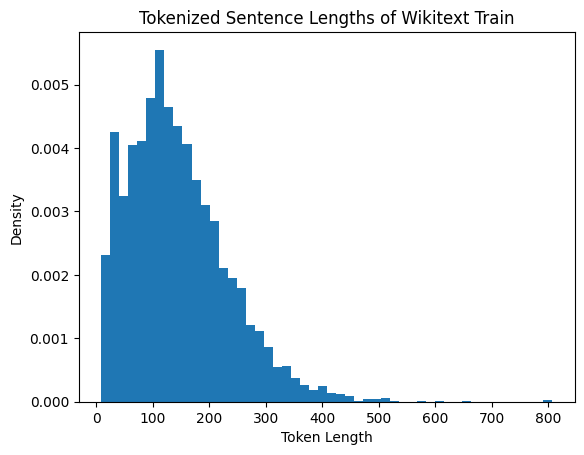

In [11]:
# plot lengths
fig, ax = plt.subplots()
ax.hist(trainset_entropies['length'][:, -1], bins=50, density=True)
ax.set_title('Tokenized Sentence Lengths of Wikitext Train')
ax.set_xlabel("Token Length")
ax.set_ylabel("Density")
plt.show()

## Histogram of entropies in the last layer

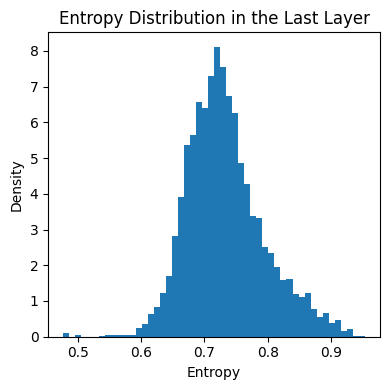

In [12]:
fig, ax = plt.subplots(figsize=(4, 4))

last_layer_entropies = trainset_entropies['maxEntropy'][:, -1]  # Get entropies from the last layer
ax.hist(last_layer_entropies, bins=50, density=True)
ax.set_title("Entropy Distribution in the Last Layer")
ax.set_xlabel("Entropy")
ax.set_ylabel("Density")

plt.tight_layout()
plt.show()

## Histogram of entropies across layers

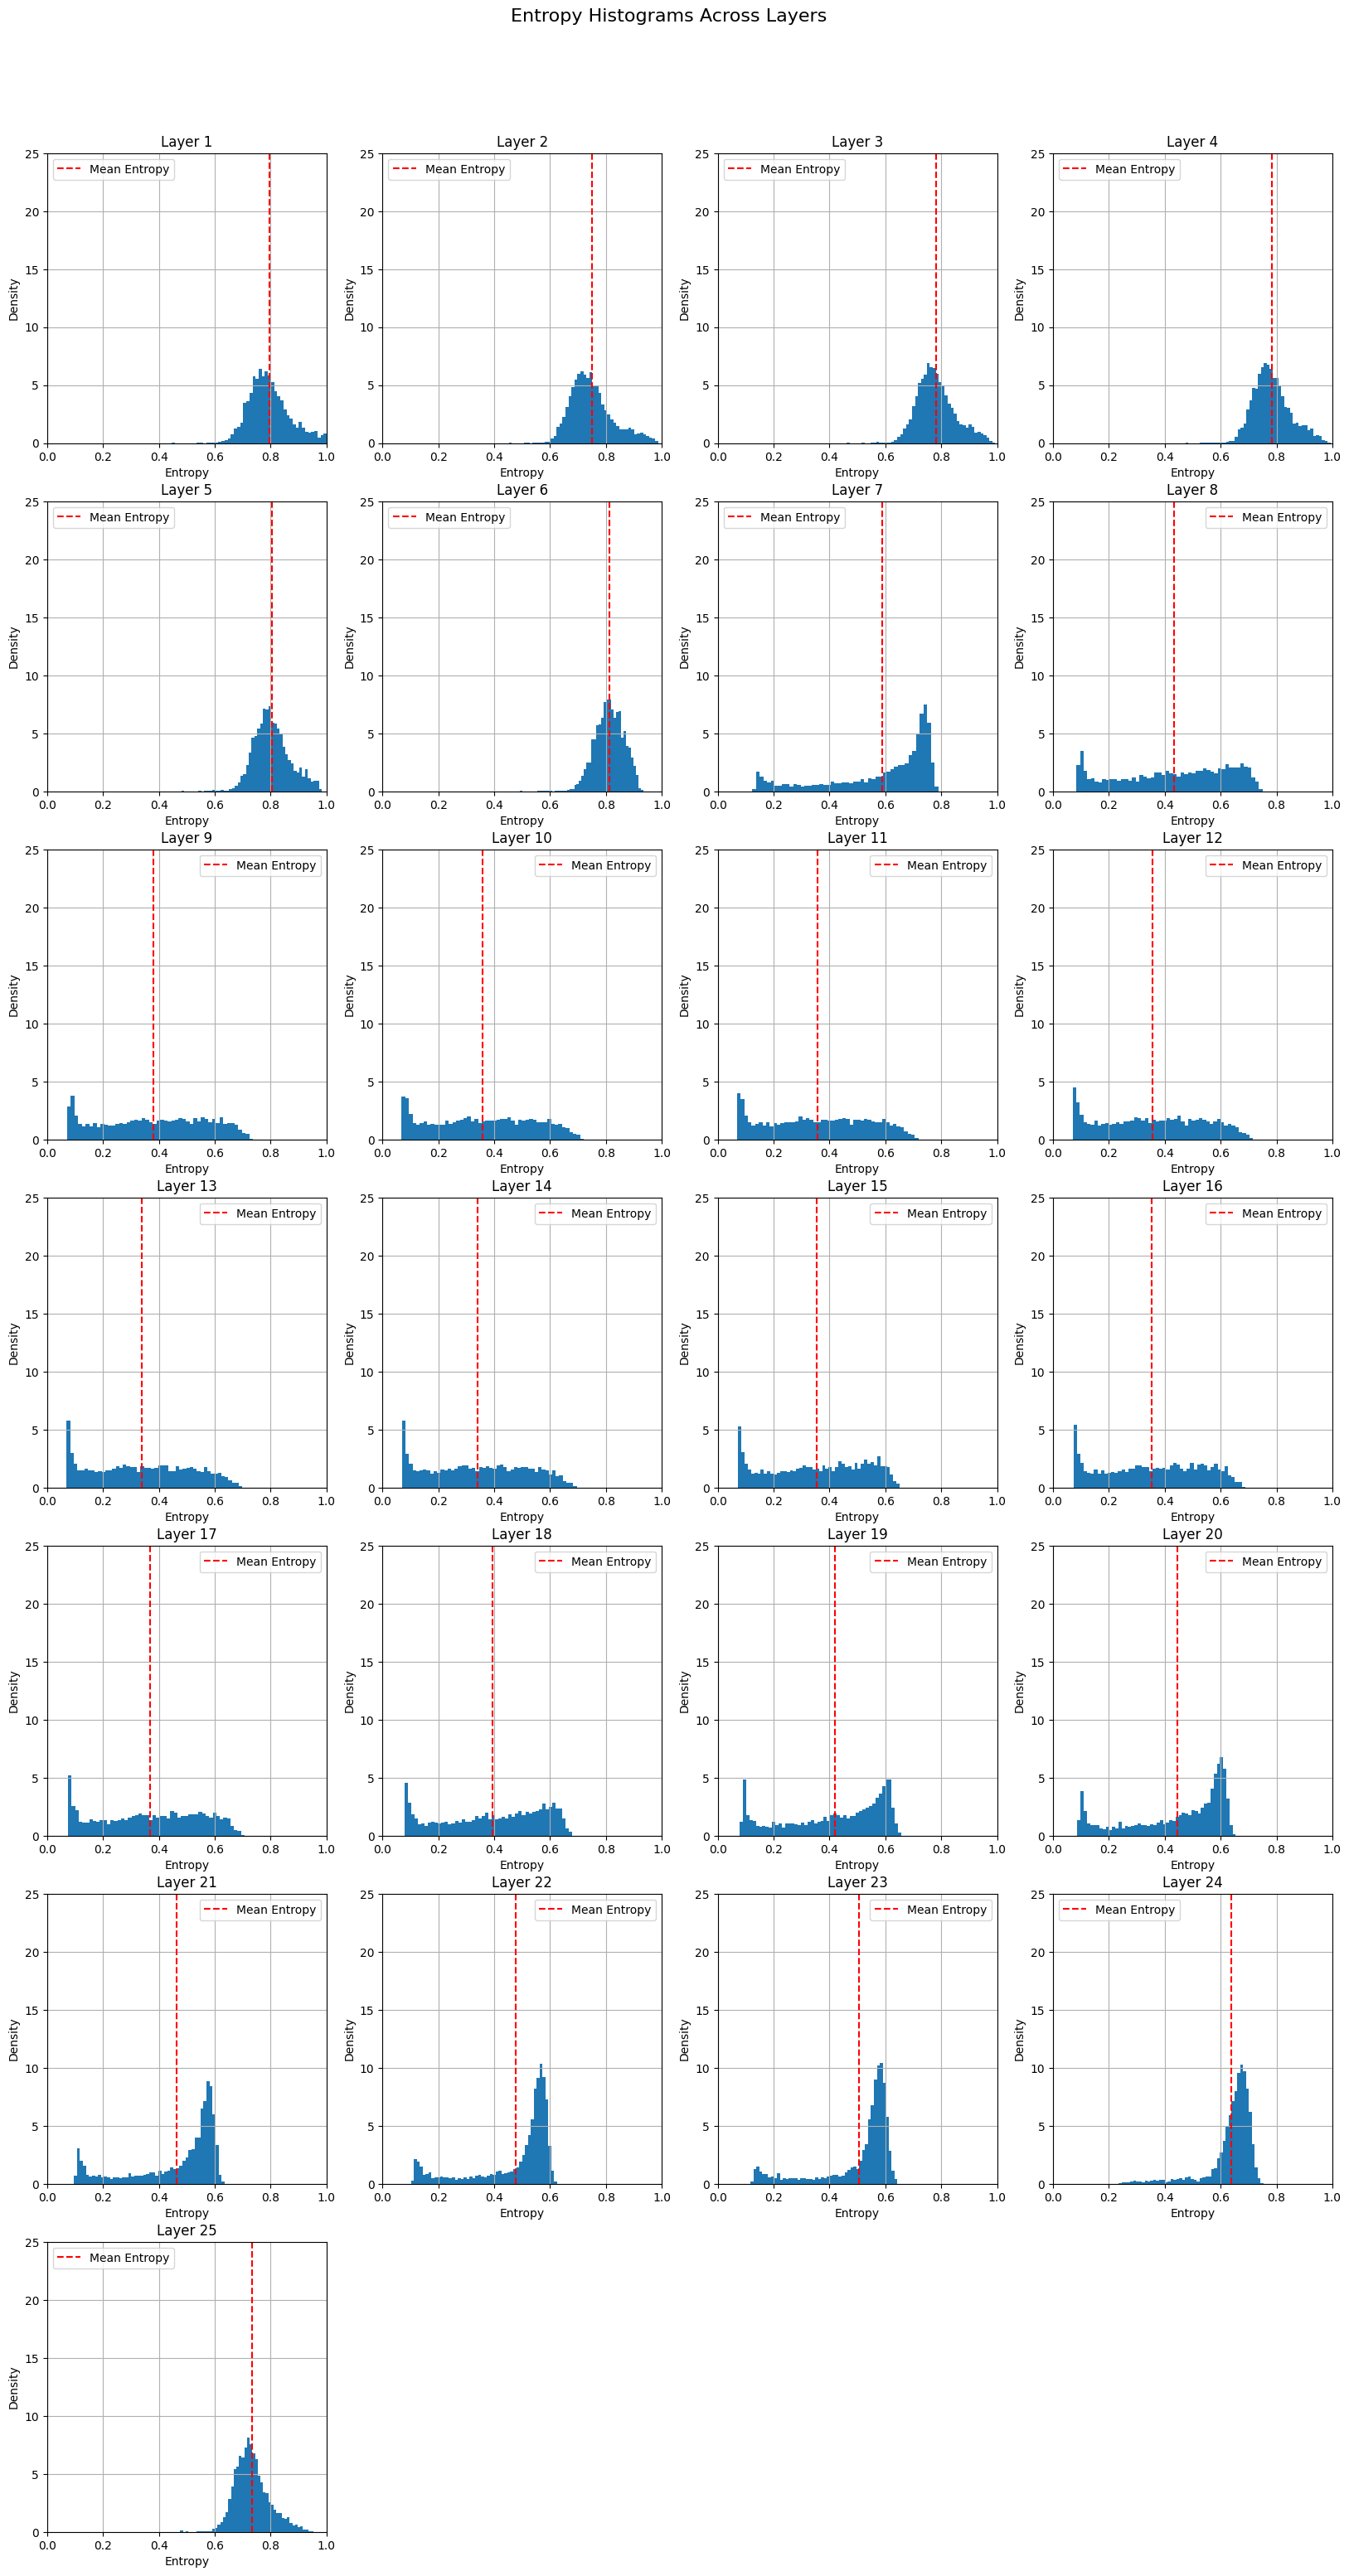

In [14]:
import pickle

# with open('medical_entropies.pkl', 'rb') as f:
#     results = pickle.load(f)
# trainset_entropies = results['Llama3']['8B']

# Create subplots to show entropy histograms across layers
num_layers = trainset_entropies['maxEntropy'].shape[1]
num_rows = (num_layers + 3) // 4  # Calculate number of rows, rounding up
fig, axes = plt.subplots(num_rows, 4, figsize=(20, 5 * num_rows), sharex=True)
axes = axes.flatten()

num_layers = trainset_entropies['maxEntropy'].shape[1]

for layer in range(num_layers):
    layer_entropies = trainset_entropies['maxEntropy'][:, layer]
    axes[layer].hist(layer_entropies, bins=50, density=True)
    axes[layer].set_title(f"Layer {layer+1}")
    axes[layer].set_ylabel("Density")
    
    axes[layer].set_xlabel("Entropy")
    axes[layer].grid(True)
    
    # Ensure x-axis ticks are visible for all subplots
    axes[layer].tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=True)
    axes[layer].set_xlim(0, 1)
    axes[layer].set_ylim(0, 25)

    # plot mean line
    mean_entropy = np.mean(layer_entropies)
    axes[layer].axvline(mean_entropy, color='red', linestyle='--', label='Mean Entropy')
    axes[layer].legend()

# Remove extra subplots if any
for i in range(num_layers, len(axes)):
    fig.delaxes(axes[i])

plt.grid(True)

fig.suptitle("Entropy Histograms Across Layers", fontsize=16)
plt.subplots_adjust(top=0.93)
plt.show()

In [65]:
[diptest.diptest(medical_entropies['maxEntropy'][:, i]) for i in range(num_layers)]


[(0.015621489753836655, 0.09974673027568337),
 (0.009134363210309516, 0.8953749012535928),
 (0.10958005925808774, 0.0),
 (0.14091074342219767, 0.0),
 (0.15235820257543467, 0.0),
 (0.13898526683091883, 0.0),
 (0.1256554959901285, 0.0),
 (0.11852353380866673, 0.0),
 (0.10975445319934964, 0.0),
 (0.10508432445006081, 0.0),
 (0.09949753769754344, 0.0),
 (0.09685386998757459, 0.0),
 (0.09547427251922957, 0.0),
 (0.09498044992203691, 0.0),
 (0.08928083013286531, 0.0),
 (0.08272980232562814, 0.0),
 (0.06012321014748845, 0.0),
 (0.027452907140723737, 2.365850766539168e-05),
 (0.007027088566285962, 0.9926335934128356),
 (0.007364576632708641, 0.9910899342597345),
 (0.005899831167785948, 0.9977896311345255),
 (0.009136044756196853, 0.8951624478198192),
 (0.016419672793856137, 0.06950316484928298),
 (0.028025098504730037, 1.4834072610603322e-05),
 (0.037973856443558336, 0.0),
 (0.04532973039935032, 0.0),
 (0.051870030247515755, 0.0),
 (0.05608696518669536, 0.0),
 (0.0624563266790687, 0.0),
 (0.06

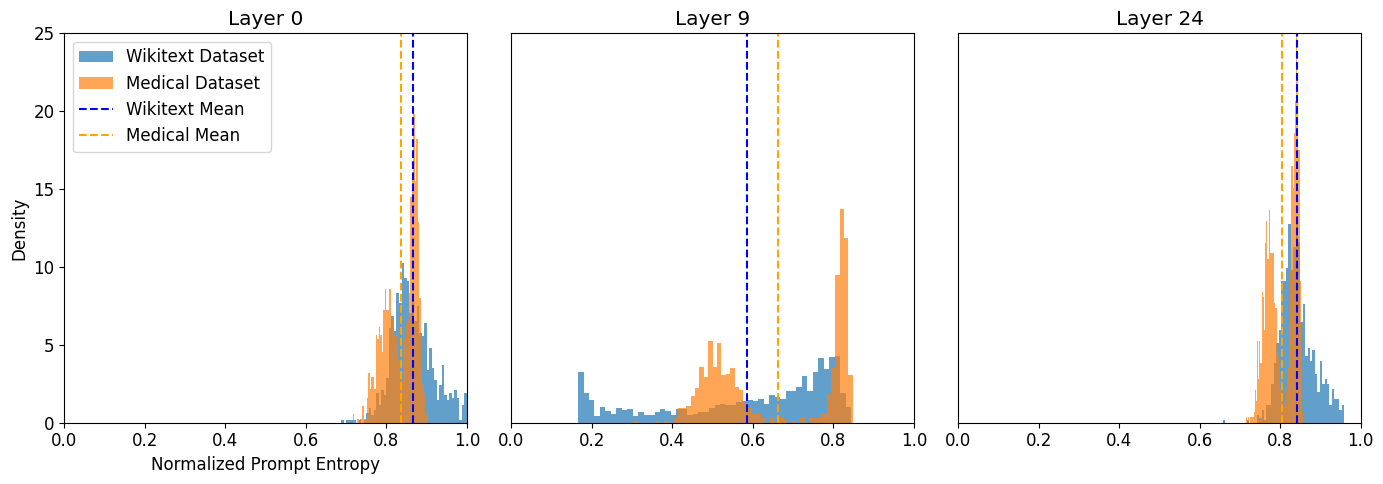

In [83]:
import pickle

import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 12})

import pickle
import matplotlib.pyplot as plt
import numpy as np
import diptest

model_name = "Pythia"
model_size = "410m"

# Load wikitext entropies
with open('wikitext_sentence_entropies.pkl', 'rb') as f:
    wikitext_results = pickle.load(f)
wikitext_entropies = wikitext_results[model_name][model_size]

# Load medical entropies
with open('medical_entropies.pkl', 'rb') as f:
    medical_results = pickle.load(f)
medical_entropies = medical_results[model_name][model_size]

# Create subplots to show entropy histograms for first, middle, and last layers
num_layers = wikitext_entropies['maxEntropy'].shape[1]
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
layer_with_max_diptest = np.argmax([diptest.dipstat(medical_entropies['maxEntropy'][:, i]) for i in range(num_layers)])
layers_to_plot = [0,  layer_with_max_diptest, num_layers - 1]  # First, middle, and last layers

for i, layer in enumerate(layers_to_plot):
    wikitext_layer_entropies = wikitext_entropies['maxEntropy'][:, layer]
    medical_layer_entropies = medical_entropies['maxEntropy'][:, layer]
    
    axes[i].hist(wikitext_layer_entropies, bins=50, density=True, alpha=0.7, label='Wikitext Dataset')
    axes[i].hist(medical_layer_entropies, bins=50, density=True, alpha=0.7, label='Medical Dataset')
    
    axes[i].set_title(f"Layer {layer}")
    axes[i].set_ylabel("Density")
    axes[i].set_xlabel("Normalized Prompt Entropy")
    
    axes[i].tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=True)
    axes[i].set_xlim(0, 1)
    axes[i].set_ylim(0, 25)

    # Plot mean lines
    wikitext_mean = np.mean(wikitext_layer_entropies)
    medical_mean = np.mean(medical_layer_entropies)
    axes[i].axvline(wikitext_mean, color='blue', linestyle='--', label='Wikitext Mean')
    axes[i].axvline(medical_mean, color='orange', linestyle='--', label='Medical Mean')
    
    if i == 0:
        axes[i].legend()

    if i != 0:
        axes[i].set_yticklabels([])
        axes[i].set_yticks([])
        axes[i].set_ylabel('')
        axes[i].set_xlabel('')


plt.tight_layout()
plt.savefig(f'figures/{model_name}_bimodal_entropies.pdf')
plt.show()

## Plot the means

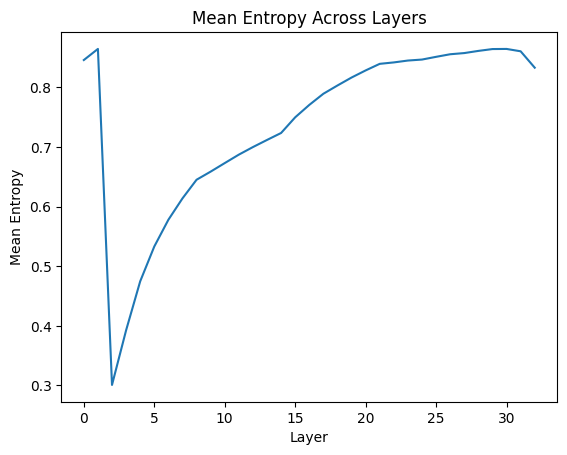

In [31]:
fig, ax = plt.subplots()
ax.plot(np.mean(trainset_entropies['maxEntropy'], axis=0))
ax.set_title("Mean Entropy Across Layers")
ax.set_xlabel("Layer")
ax.set_ylabel("Mean Entropy")
plt.show()


## Cumulative Distribution of Entropy

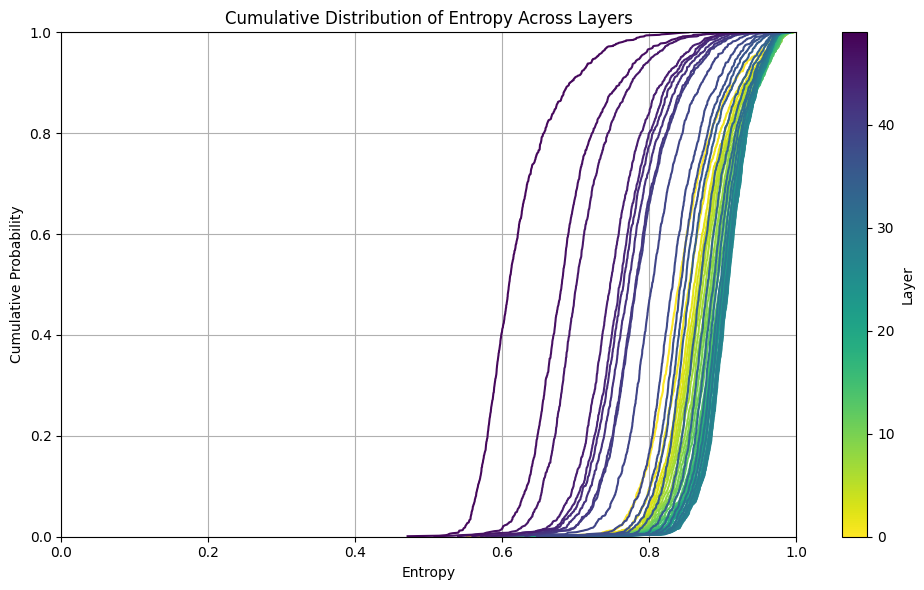

In [51]:
import matplotlib

fig, ax = plt.subplots(figsize=(10, 6))

num_layers = trainset_entropies['maxEntropy'].shape[1]
cmap = plt.cm.viridis_r
norm = matplotlib.colors.Normalize(vmin=0, vmax=num_layers)  # Adjusted vmin to 0.2 to make lightest color darker

for layer in range(num_layers):
    layer_entropies = trainset_entropies['maxEntropy'][:, layer]
    sorted_entropies = np.sort(layer_entropies)
    cumulative = np.arange(1, len(sorted_entropies) + 1) / len(sorted_entropies)

    color = cmap(norm(layer))
    ax.plot(sorted_entropies, cumulative, label=f'Layer {layer+1}', color=color)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title("Cumulative Distribution of Entropy Across Layers")
ax.set_xlabel("Entropy")
ax.set_ylabel("Cumulative Probability")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Layer')

ax.grid(True)
plt.tight_layout()
plt.show()

## Skewness of Entropy Distribution across layers

Text(0, 0.5, 'Skewness')

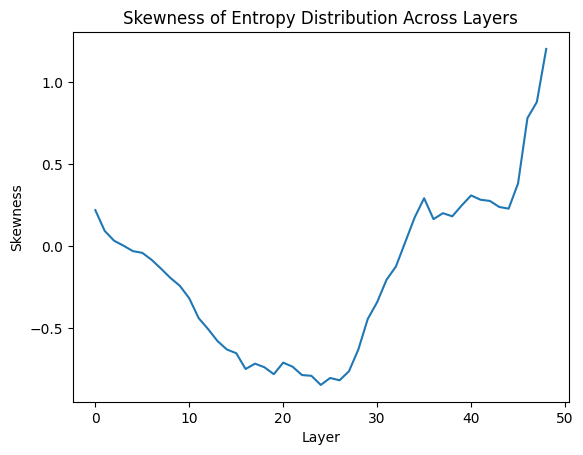

In [52]:
import scipy.stats as stats
fig, ax = plt.subplots()
skewness = np.zeros(num_layers)
for layer in range(num_layers):
    layer_entropies = trainset_entropies['maxEntropy'][:, layer]
    skewness[layer] = stats.skew(layer_entropies)

ax.plot(skewness)
ax.set_title("Skewness of Entropy Distribution Across Layers")
ax.set_xlabel("Layer")
ax.set_ylabel("Skewness")


## A look at the sentences with highest entropy

In [21]:
def get_extreme_entropy_sentences(tokenizer, dataloader, entropies, highest=True, normalization='raw', num_sentences=5, layer=-1):
    """
    Get the sentences with the highest or lowest entropy.
    """
    # Use the specified layer for entropy values
    layer_entropies = entropies[normalization][:, layer]

    # Get indices of extreme entropy sentences
    if highest:
        extreme_indices = np.argsort(layer_entropies)[-num_sentences:][::-1]
    else:
        extreme_indices = np.argsort(layer_entropies)[:num_sentences]

    # Get the extreme entropy sentences
    extreme_sentences = []
    for idx in extreme_indices:
        # Convert numpy.int64 to Python int
        idx = int(idx)
        batch = next(iter(torch.utils.data.Subset(dataloader.dataset, [idx])))
        decoded_sentence = tokenizer.decode(batch['input_ids'])
        extreme_sentences.append((layer_entropies[idx], decoded_sentence))

    return extreme_sentences

### Unnormalized entropy

Sentences with extreme unnormalized entropy. Keep in mind that the length affects the entropy measure

In [32]:
model_specs = ModelSpecifications(
    model_family="Pythia",
    model_size="410m",
    revision="main"
)
model = AutoModelWrapper(model_specs)
dataloader = get_dataloader(model.tokenizer, "ai-medical-dataset", split="train", num_samples=10000, min_length=30)


/home/AD/ofsk222/miniconda3/envs/information_plane/lib/python3.10/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


Number of GPUs: 2


Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/18 [00:00<?, ?it/s]

In [40]:


extreme_sentences = get_extreme_entropy_sentences(model.tokenizer, dataloader, trainset_entropies, highest=True, num_sentences=5, layer=3)
for entropy, sentence in extreme_sentences:
    print(f"Entropy: {entropy:.4f}")
    print(f"Sentence: {sentence}\n")

Entropy: 5.2383
Sentence: You are an AI Medical Assistant Chatbot, trained to answer medical questions. Below is an instruction that describes a task, paired with an response context. Write a response that appropriately completes the request.

            ### Instruction:
            What is the new model to reduce unnecessary Prostate Biopsies


            ### Response:
            Developing a Follow-Up Strategy for Patients with PSA Ranging from 4 to 10 ng/ml via a New Model to Reduce Unnecessary Prostate Biopsies.

Entropy: 5.2339
Sentence: You are an AI Medical Assistant Chatbot, trained to answer medical questions. Below is an instruction that describes a task, paired with an response context. Write a response that appropriately completes the request.

            ### Instruction:
            What is the LSEPAELTDAVK peptide?


            ### Response:
            Context.-Prostate-specific antigen (PSA) is a 34-kDa glycoprotein with chymotrypsin-like enzyme activity that circu

In [37]:
extreme_sentences = get_extreme_entropy_sentences(model.tokenizer, dataloader, trainset_entropies, highest=False, num_sentences=5, layer=-1)
for entropy, sentence in extreme_sentences:
    print(f"Entropy: {entropy:.4f}")
    print(f"Sentence: {sentence}\n")

Entropy: 3.5117
Sentence: You are an AI Medical Assistant Chatbot, trained to answer medical questions. Below is an instruction that describes a task, paired with an response context. Write a response that appropriately completes the request.

            ### Instruction:
            What is the name of the two peptides produced from?


            ### Response:
            Orexins (hypocretins) are two peptides (orexin A and B) produced from the pre-pro-orexin precursor and expressed in a limited region of dorsolateral hypothalamus. Orexins were originally thought to specifically mediate feeding and promote wakefulness, but it is now clear that they participate in a wide range of behavioral and physiological processes under select circumstances. Orexins primarily mediate behavior under situations of high motivational relevance, such as during physiological need states, exposure to threats or reward opportunities. We hypothesize that many behavioral functions of orexins (including regu

### Normalized Entropy

In [43]:
extreme_sentences = get_extreme_entropy_sentences(model.tokenizer, dataloader, trainset_entropies, highest=True, normalization='maxEntropy', num_sentences=3, layer=3)
for entropy, sentence in extreme_sentences:
    print(f"Entropy: {entropy:.4f}")
    print(f"Sentence: {sentence}\n")

Entropy: 0.7977
Sentence: You are an AI Medical Assistant Chatbot, trained to answer medical questions. Below is an instruction that describes a task, paired with an response context. Write a response that appropriately completes the request.

            ### Instruction:
            What is the new model to reduce unnecessary Prostate Biopsies


            ### Response:
            Developing a Follow-Up Strategy for Patients with PSA Ranging from 4 to 10 ng/ml via a New Model to Reduce Unnecessary Prostate Biopsies.

Entropy: 0.7876
Sentence: You are an AI Medical Assistant Chatbot, trained to answer medical questions. Below is an instruction that describes a task, paired with an response context. Write a response that appropriately completes the request.

            ### Instruction:
            What is the LSEPAELTDAVK peptide?


            ### Response:
            Context.-Prostate-specific antigen (PSA) is a 34-kDa glycoprotein with chymotrypsin-like enzyme activity that circu

In [42]:
extreme_sentences = get_extreme_entropy_sentences(model.tokenizer, dataloader, trainset_entropies, highest=False, normalization='maxEntropy', num_sentences=5, layer=3)
for entropy, sentence in extreme_sentences:
    print(f"Entropy: {entropy:.4f}")
    print(f"Sentence: {sentence}\n")

Entropy: 0.0819
Sentence: You are an AI Medical Assistant Chatbot, trained to answer medical questions. Below is an instruction that describes a task, paired with an response context. Write a response that appropriately completes the request.

            ### Instruction:
            What is the name of the two peptides produced from?


            ### Response:
            Orexins (hypocretins) are two peptides (orexin A and B) produced from the pre-pro-orexin precursor and expressed in a limited region of dorsolateral hypothalamus. Orexins were originally thought to specifically mediate feeding and promote wakefulness, but it is now clear that they participate in a wide range of behavioral and physiological processes under select circumstances. Orexins primarily mediate behavior under situations of high motivational relevance, such as during physiological need states, exposure to threats or reward opportunities. We hypothesize that many behavioral functions of orexins (including regu

## Prompt that travels the most

In [59]:
def get_highest_variance_sentences(tokenizer, dataloader, entropies, num_sentences=5, most_variance=True):
    """
    Get the sentences with the highest variance in entropy across layers.
    """

    # Get the indices of the sentences with the highest variance in entropy
    variance = np.var(entropies['maxEntropy'], axis=1)

    if most_variance:   
        highest_variance_indices = np.argsort(variance)[-num_sentences:][::-1]
    else:
        highest_variance_indices = np.argsort(variance)[:num_sentences]

    # Get the extreme entropy sentences
    extreme_sentences = []
    for idx in highest_variance_indices:
        idx = int(idx)
        batch = next(iter(torch.utils.data.Subset(dataloader.dataset, [idx])))
        decoded_sentence = tokenizer.decode(batch['input_ids'])
        extreme_sentences.append((variance[idx], decoded_sentence))
    print(highest_variance_indices)
    return extreme_sentences, highest_variance_indices

[ 46 746 585 176  11]
Variance: 0.0796
Sentence: You are an AI Medical Assistant Chatbot, trained to answer medical questions. Below is an instruction that describes a task, paired with an response context. Write a response that appropriately completes the request.

            ### Instruction:
            What is the name of the two peptides produced from?


            ### Response:
            Orexins (hypocretins) are two peptides (orexin A and B) produced from the pre-pro-orexin precursor and expressed in a limited region of dorsolateral hypothalamus. Orexins were originally thought to specifically mediate feeding and promote wakefulness, but it is now clear that they participate in a wide range of behavioral and physiological processes under select circumstances. Orexins primarily mediate behavior under situations of high motivational relevance, such as during physiological need states, exposure to threats or reward opportunities. We hypothesize that many behavioral functions of 

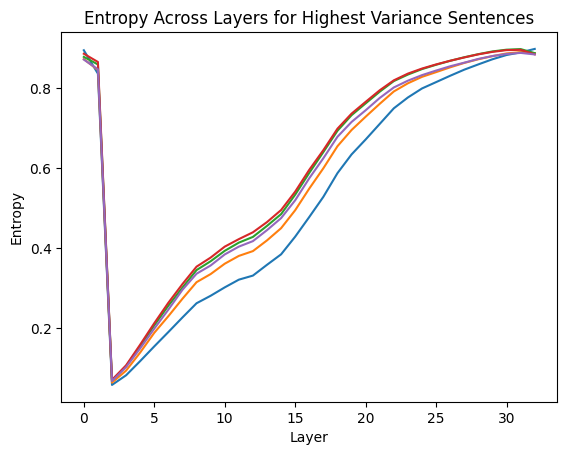

In [109]:
highest_variance_sentences, highest_variance_indices = get_highest_variance_sentences(model.tokenizer, dataloader, trainset_entropies, num_sentences=5, most_variance=True)
for entropy, sentence in highest_variance_sentences:
    print(f"Variance: {entropy:.4f}")
    print(f"Sentence: {sentence}\n")

fig, ax = plt.subplots()

# plot the entrpoies across layers for the highest variance sentences
for idx in highest_variance_indices:
    ax.plot(trainset_entropies['maxEntropy'][idx])
ax.set_title("Entropy Across Layers for Highest Variance Sentences")
ax.set_xlabel("Layer")
ax.set_ylabel("Entropy")
plt.show()

[106 285 494 201 549]
Variance: 0.0006
Sentence: You are an AI Medical Assistant Chatbot, trained to answer medical questions. Below is an instruction that describes a task, paired with an response context. Write a response that appropriately completes the request.

            ### Instruction:
            What is the new model to reduce unnecessary Prostate Biopsies


            ### Response:
            Developing a Follow-Up Strategy for Patients with PSA Ranging from 4 to 10 ng/ml via a New Model to Reduce Unnecessary Prostate Biopsies.

Variance: 0.0006
Sentence: You are an AI Medical Assistant Chatbot, trained to answer medical questions. Below is an instruction that describes a task, paired with an response context. Write a response that appropriately completes the request.

            ### Instruction:
            What is the effect of social support and self-concept on depressive symptoms in adults with


            ### Response:
            Mediating effects of social suppo

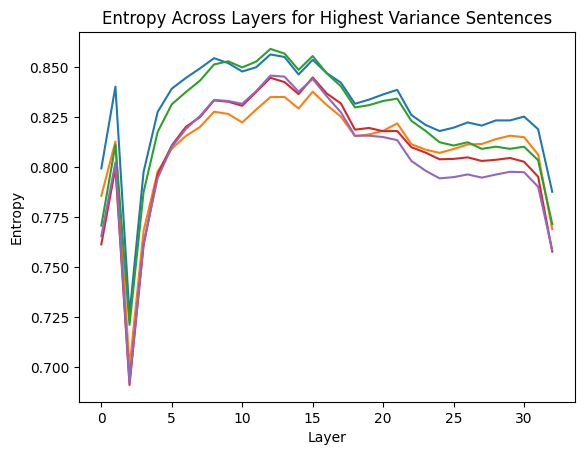

In [60]:
highest_variance_sentences, highest_variance_indices = get_highest_variance_sentences(model.tokenizer, dataloader, trainset_entropies, num_sentences=5, most_variance=False)
for entropy, sentence in highest_variance_sentences:
    print(f"Variance: {entropy:.4f}")
    print(f"Sentence: {sentence}\n")

fig, ax = plt.subplots()

# plot the entrpoies across layers for the highest variance sentences
for idx in highest_variance_indices:
    ax.plot(trainset_entropies['maxEntropy'][idx])
ax.set_title("Entropy Across Layers for Highest Variance Sentences")
ax.set_xlabel("Layer")
ax.set_ylabel("Entropy")
plt.show()

# Comparing across model architectures

In [ ]:

families = ['Pythia', "LLM2Vec-mntp", "mamba", "Llama3", "LLM2Vec-mntp-unsup-simcse", "llama-instruct", "Medical-Llama3"]
family_to_sizes = {
    'Pythia': ['14m', '70m', '160m', '410m', '1b', '2.7B', '6.7B'],
    'LLM2Vec-mntp': ['8B'],
    'mamba': ['130m', '370m', '790m',  '1.4b', '2.8b'],
    'Llama3': ['8B'],
    "LLM2Vec-mntp-unsup-simcse": ['8B'],
    "llama-instruct": ['8B'],
    "Medical-Llama3": ['8B']
}


results = {}

for family in families:
    if family not in results:
        results[family] = {}

    for size in family_to_sizes[family]:
        try:
            model_specs = ModelSpecifications(
                model_family=family,
            model_size=size,
                revision="main"
            )
            model = AutoModelWrapper(model_specs, device_map="auto")

            dataloader = get_dataloader(model.tokenizer, "ai-medical-dataset", split="train", num_samples=5000, min_length=30)
            trainset_entropies = compute_sentence_entropies(model, dataloader, alpha=1)
            results[family][size] = trainset_entropies
        except Exception as e:
            print(f"Error: {e}")
            continue


In [72]:
# save results
import pickle

# with open('wikitext_sentence_entropies.pkl', 'rb') as f:
#     results = pickle.load(f)

with open('medical_entropies.pkl', 'rb') as f:
    results = pickle.load(f)

In [1]:
import scipy
from scipy.stats import entropy
import diptest

moments = ['mean', 'Std. Dev', 'diptest']
fig, axes = plt.subplots(1, len(moments), figsize=(15, 5))

# rearrange so that Pythia and Mamba are first
#tmp_familes = ['Pythia', 'mamba', 'Llama3', 'llama-instruct', "Medical-Llama3", 'LLM2Vec-mntp', 'LLM2Vec-mntp-unsup-simcse']
tmp_familes = ['Pythia', 'mamba', 'Llama3']
family_to_display_name = {
    'Pythia': 'Pythia',
    'mamba': 'Mamba',
    'LLM2Vec-mntp': 'LLM2Vec-mntp',
    'Llama3': 'Llama3',
    "LLM2Vec-mntp-unsup-simcse": "LLM2Vec-simcse",
    "llama-instruct": "Llama3-Instruct",
    "Medical-Llama3": "Medical-Llama3"
}
for i, moment in enumerate(moments):
    for family in tmp_familes:
        display_name = family_to_display_name[family]
        sizes = list(results[family].keys())
        if family == 'Pythia':
            sizes = [size for size in sizes if size not in ['14m', '1.4b', '2.8b', '6.9b']]
        # Create color gradient
        if family == 'Pythia':
            color = plt.cm.get_cmap('Greens')(np.linspace(0.5, 1, len(sizes)))
        elif family == 'mamba':
            color = plt.cm.get_cmap('Blues')(np.linspace(0.5, 1, len(sizes)))
        elif 'llama' in family.lower():
            color = plt.cm.get_cmap('Oranges')(np.linspace(0.5, 1, len(sizes)))
        else:
            color = plt.cm.get_cmap('Purples')(np.linspace(0.5, 1, len(sizes)))

        
        for j, size in enumerate(sizes):
            num_layers = results[family][size]['maxEntropy'].shape[1]
            x = range(num_layers)
            y = []
            for layer in x:
                normalization = 'maxEntropy'
                if moment == 'mean':
                    y.append(np.mean(results[family][size][normalization][:, layer]))
                    axes[i].set_ylim(0, 1)

                elif moment == 'Std. Dev':
                    y.append(np.std(results[family][size][normalization][:, layer]))
                    axes[i].set_ylim(0, 0.3)
                elif moment == 'skew':
                    y.append(scipy.stats.skew(results[family][size][normalization][:, layer]))
                elif moment == 'Shannon Entropy':
                    hist1 = np.histogram(results[family][size][normalization][:, layer], bins=100, range=(0,1), density=True)
                    data = hist1[0]
                    ent = -(data*np.log(np.abs(data))).sum()
                    y.append(entropy(results[family][size][normalization][:, layer]))
                elif moment == 'kurtosis':
                    y.append(scipy.stats.kurtosis(results[family][size][normalization][:, layer]))
                elif moment == 'diptest':
                    y.append(diptest.dipstat(results[family][size][normalization][:, layer]))
                    axes[i].set_ylim(0, 0.2)
     
            depth_percentage = [x/num_layers for x in x]
            color_idx = sizes.index(size)
            label = display_name if j == 0 else None  # Only label the first line for each family

            if family == 'llama-instruct' or family == 'LLM2Vec-mntp-unsup-simcse':
                style = '--'
            elif family == 'Medical-Llama3':
                style = ':'
            else:
                style = '-'

            axes[i].plot(depth_percentage, y, c=color[color_idx], label=label, linestyle=style)
    axes[i].grid(True)
    axes[i].set_title(f'{moment.capitalize()} of Normalized Sentence Entropies')
    axes[i].set_xlabel('Percent of Depth')
    axes[i].set_ylabel(f'{moment.capitalize()} of Normalized Sentence Entropy')

    if i == 0:
        axes[i].legend()

plt.tight_layout()

NameError: name 'plt' is not defined

# Datasets with Varying Degrees of Intensity

In [26]:
import random
import tqdm
def make_wikitext_with_randomness(tokenizer, old_dataloader, random_strength=0.1):
    """
    Make tokens in old_dataloader random with probability proportional to random_strength
    """
    assert 0 <= random_strength <= 1, "random_strength must be between 0 and 1"
    random.seed(42)

    new_dataloader = []
    for sample in tqdm.tqdm(old_dataloader):
        input_ids = sample['input_ids'].tolist()[0]

        new_input_ids = []
        for token in input_ids:
            if random.random() < random_strength:
                new_input_ids.append(random.randint(20, len(tokenizer.vocab) - 1))
            else:
                new_input_ids.append(token)
        new_dataloader.append({'input_ids': torch.tensor(new_input_ids).unsqueeze(0), 'attention_mask': sample['attention_mask']})

    return new_dataloader

def make_completely_random_of_length(tokenizer, num_samples, length=10):
    """
    Make a sentence of a given length with random tokens
    """
    new_dataloader = []

    random.seed(42)
    torch.manual_seed(42)

    for idx in tqdm.tqdm(range(num_samples)):
        input_ids = torch.randint(20, len(tokenizer.vocab), (length,)).tolist()
        attention_mask = [1] * length
        new_dataloader.append({'input_ids': torch.tensor(input_ids).unsqueeze(0), 'attention_mask': torch.tensor(attention_mask).unsqueeze(0)})
    return new_dataloader

def make_wikitext_with_repetition(old_dataloader, repetition_strength=0.1):
    """
    Select a random token. Make repetition_strength percent of tokens in the sentence equal to that token.
    """
    assert 0 <= repetition_strength <= 1, "repetition_strength must be between 0 and 1"
    # seed
    random.seed(42)
    new_dataloader = []

    for sample in tqdm.tqdm(old_dataloader):
        input_ids = sample['input_ids'].tolist()[0]
        chosen_token = random.choice(input_ids)
        new_input_ids = []
        for token in input_ids:
            if random.random() < repetition_strength:
                new_input_ids.append(chosen_token)
            else:
                new_input_ids.append(token)
        new_dataloader.append({'input_ids': torch.tensor(new_input_ids).unsqueeze(0), 'attention_mask': sample['attention_mask']})

    return new_dataloader

In [1]:
import pickle

with open('pythia_randomness.pkl', 'rb') as f:
    randomness_results = pickle.load(f)

with open('pythia_repetition.pkl', 'rb') as f:
    repetition_results = pickle.load(f)

### Increasing Randomness

In [4]:
model_specs = ModelSpecifications(
    model_family="Pythia",
    model_size="410m",
    revision="main"
)
model = AutoModelWrapper(model_specs, device_map="auto")

dataloader = get_dataloader(model.tokenizer, "wikitext", split="train", num_samples=5000, min_length=30)

/home/AD/ofsk222/miniconda3/envs/information_plane/lib/python3.10/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


Number of GPUs: 2


In [10]:
samples = []
for sample in dataloader:
    input_ids = sample['input_ids'].tolist()[0]
    decoded_sentence = model.tokenizer.decode(input_ids)
    print(decoded_sentence)
    samples.append(sample)
    break


 Mint records indicate the first gold dollars were produced on May 7, 1849 ; Longacre's diary notes state instead that the first were struck on May 8. A few coins in proof condition were struck on the first day, along with about 1 @,@ 000 for circulation. There are five major varieties of the 1849 gold dollar from Philadelphia, made as Longacre continued to fine @-@ tune the design. <unk> dies were sent by Longacre's Engraving Department at the Philadelphia Mint to the branch mints at Charlotte, Dahlonega ( in Georgia ), and New Orleans ; coins struck at the branches resemble some of the types issued from Philadelphia, depending on when the dies were produced. Of the coins struck at the branch mints in 1849, only pieces struck at Charlotte ( 1849 @-@ C ) exist in multiple varieties ; most are of what is dubbed the " Closed Wreath " variety. Approximately five of the 1849 @-@ C Open Wreath are known ; one, believed the finest surviving specimen, sold at auction for $ 690 @,@ 000 in 2004

In [30]:
levels = [0.0, 0.1, 0.5, 1.0]
for level in levels:
    new_dataloader = make_completely_random_of_length(model.tokenizer, num_samples=1, length=16)

    for sample in new_dataloader:
        input_ids = sample['input_ids'].tolist()[0]
        decoded_sentence = model.tokenizer.decode(input_ids)
        print(decoded_sentence)
        break

100%|██████████| 1/1 [00:00<00:00, 33.91it/s]


 Proposition Sequencespecific Exp fibers brows ##Club overviewNos toss Thinking traderMulti indoorlis


100%|██████████| 1/1 [00:00<00:00, 37.40it/s]


 Proposition Sequencespecific Exp fibers brows ##Club overviewNos toss Thinking traderMulti indoorlis


100%|██████████| 1/1 [00:00<00:00, 35.97it/s]


 Proposition Sequencespecific Exp fibers brows ##Club overviewNos toss Thinking traderMulti indoorlis


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00, 46.94it/s]

 Proposition Sequencespecific Exp fibers brows ##Club overviewNos toss Thinking traderMulti indoorlis


In [31]:
model_specs = ModelSpecifications(
    model_family="Pythia",
    model_size="410m",
    revision="main"
)
model = AutoModelWrapper(model_specs, device_map="auto")

dataloader = get_dataloader(model.tokenizer, "wikitext", split="train", num_samples=5000, min_length=30)
randomness_levels = np.linspace(0, 1, 10)
results = {}
for randomness_level in randomness_levels:
    new_dataloader = make_wikitext_with_randomness(model.tokenizer, dataloader, randomness_level)
    trainset_entropies = compute_sentence_entropies(model, new_dataloader, alpha=1)
    results[randomness_level] = trainset_entropies

with open(f'pythia_randomness.pkl', 'wb') as f:
    pickle.dump(results, f)

/home/AD/ofsk222/miniconda3/envs/information_plane/lib/python3.10/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


Number of GPUs: 2


KeyboardInterrupt: 

In [5]:
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 12})

import cmasher as cmr
import numpy as np

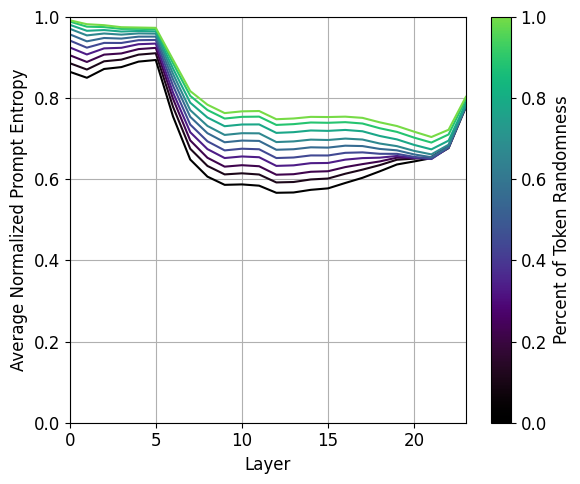

In [20]:
# plot pythia randomness
fig, ax = plt.subplots(figsize=(6, 5))
randomness_levels = list(randomness_results.keys())
colors = cmr.lavender(np.linspace(0, 1, len(randomness_levels)))
cmap = cmr.lavender
norm = plt.Normalize(vmin=0, vmax=1)

PLOT_STDEV = False
PLOT_DIPTEST = False
normalization = 'maxEntropy'

for randomness_level, color in zip(randomness_levels, colors):
    if PLOT_STDEV:
        stddev = np.std(randomness_results[randomness_level][normalization], axis=0)
    elif PLOT_DIPTEST:
        layerwise_dipstats = [diptest.dipstat(randomness_results[randomness_level][normalization][:, layer]) for layer in range(randomness_results[randomness_level][normalization].shape[1])]
        ax.plot(layerwise_dipstats, color=color)
    else:
        ax.plot(randomness_results[randomness_level][normalization].mean(axis=0), color=color)
ax.set_xlabel("Layer")
ax.set_ylabel("Average Normalized Prompt Entropy")
ax.set_ylim(0, 1)
ax.set_xlim(0, 23)
ax.grid()

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Percent of Token Randomness')
plt.tight_layout()
plt.savefig('figures/pythia_increasing_randomness.pdf')

### Response to randomness across training

In [30]:
dataloader = make_completely_random_of_length(model.tokenizer, num_samples=1000, length=512)
dataloader = torch.utils.data.DataLoader(dataloader, batch_size=16, shuffle=False)

100%|██████████| 1000/1000 [00:18<00:00, 54.63it/s]


In [35]:
revisions = ["step1", "step64", "step128", "step256", "step512", "step1000", "step2000", "step4000", "step8000", "step16000", "step32000", "step64000", "step128000", "main"]
results = {}

for revision in revisions:
    model_specs = ModelSpecifications(
        model_family="Pythia",
        model_size="410m",
        revision=revision
    )
    model = AutoModelWrapper(model_specs, device_map="auto")
    
    trainset_entropies = compute_sentence_entropies(model, dataloader, alpha=2)
    results[revision] = trainset_entropies

with open(f'pythia_random_sentences_across_revisions.pkl', 'wb') as f:
    pickle.dump(results, f)

/home/AD/ofsk222/miniconda3/envs/information_plane/lib/python3.10/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


Number of GPUs: 2


Processing batches:  98%|█████████▊| 62/63 [00:17<00:00,  3.53it/s]
/home/AD/ofsk222/miniconda3/envs/information_plane/lib/python3.10/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


Number of GPUs: 2


Processing batches:  98%|█████████▊| 62/63 [00:17<00:00,  3.53it/s]
/home/AD/ofsk222/miniconda3/envs/information_plane/lib/python3.10/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


...

Processing batches:  98%|█████████▊| 62/63 [00:17<00:00,  3.53it/s]
/home/AD/ofsk222/miniconda3/envs/information_plane/lib/python3.10/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


Number of GPUs: 2


Processing batches:  98%|█████████▊| 62/63 [00:17<00:00,  3.52it/s]
/home/AD/ofsk222/miniconda3/envs/information_plane/lib/python3.10/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


Number of GPUs: 2


Processing batches:  98%|█████████▊| 62/63 [00:17<00:00,  3.52it/s]


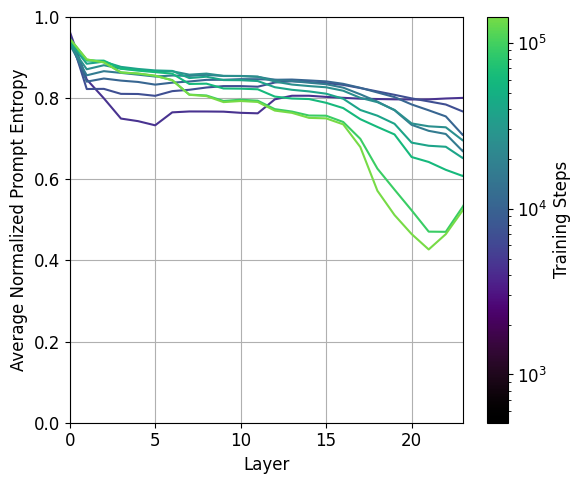

In [19]:
# plot pythia revisions
results = pickle.load(open(f'pythia_random_sentences_across_revisions.pkl', 'rb'))
fig, ax = plt.subplots(figsize=(6, 5))
revisions = list(results.keys())
steps = [int(revision.split("step")[1]) for revision in revisions if ("step" in revision)] + [143000]

colors = cmr.lavender(np.linspace(0, 1, len(steps)))
cmap = cmr.lavender
norm =  matplotlib.colors.LogNorm(vmin=steps[4], vmax=max(steps))

for idx, (revision, color) in enumerate(zip(revisions, colors)):
    if idx > 4:
        ax.plot(results[revision]['maxEntropy'].mean(axis=0), color=color, label=revision)

ax.set_xlabel("Layer")
ax.set_ylabel("Average Normalized Prompt Entropy")
ax.set_ylim(0, 1)
ax.set_xlim(0, 23)
ax.grid()

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Training Steps')
plt.tight_layout()
plt.savefig('figures/pythia_random_sentences_across_revisions.pdf')


### Sentences with Increasing Repetition

In [ ]:
model_specs = ModelSpecifications(
    model_family="Pythia",
    model_size="410m",
    revision="main"
)
model = AutoModelWrapper(model_specs, device_map="auto")

dataloader = get_dataloader(model.tokenizer, "wikitext", split="train", num_samples=5000, min_length=30)
repetition_levels = np.linspace(0, 0.9, 9)
results = {}
for repetition_level in repetition_levels:
    new_dataloader = make_wikitext_with_repetition(model.tokenizer, dataloader, repetition_level)
    trainset_entropies = compute_sentence_entropies(model, new_dataloader, alpha=1)
    results[repetition_level] = trainset_entropies

with open(f'pythia_repetition.pkl', 'wb') as f:
    pickle.dump(results, f)

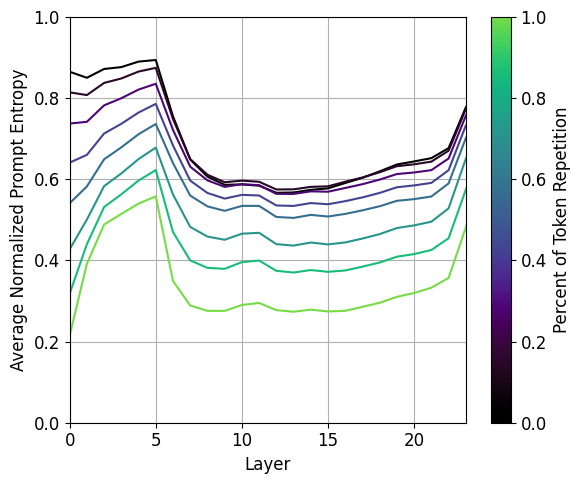

In [15]:
# plot pythia repetition
fig, ax = plt.subplots(figsize=(6, 5))
repetition_levels = list(repetition_results.keys())
colors = cmr.lavender(np.linspace(0, 1, len(repetition_levels)))
cmap = cmr.lavender
norm = plt.Normalize(vmin=0, vmax=1)

PLOT_STDEV = False
PLOT_DIPTEST = False

for repetition_level, color in zip(repetition_levels, colors):
    if PLOT_STDEV:
        stddev = np.std(repetition_results[repetition_level]['maxEntropy'], axis=0)
        ax.plot(stddev, color=color)
    elif PLOT_DIPTEST:
        layerwise_dipstats = [diptest.dipstat(repetition_results[repetition_level]['maxEntropy'][:, layer]) for layer in range(repetition_results[repetition_level]['maxEntropy'].shape[1])]
        ax.plot(layerwise_dipstats, color=color)
    else:
        ax.plot(repetition_results[repetition_level]['maxEntropy'].mean(axis=0), color=color)
ax.set_xlabel("Layer")
ax.set_ylabel("Average Normalized Prompt Entropy")
ax.set_ylim(0, 1)
ax.set_xlim(0, 23)
ax.grid()

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)

sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Percent of Token Repetition')
plt.tight_layout()
plt.savefig('figures/pythia_increasing_repetition.pdf')

### Random Sentences of Increasing Length

In [9]:
model_specs = ModelSpecifications(
    model_family="Pythia",
    model_size="410m",
    revision="main"
)
model = AutoModelWrapper(model_specs, device_map="auto")

lengths = np.logspace(6, 11, 6, base=2, dtype=int)
results = {}
for length in lengths:
    try:    
        print(f"doing length {length}")
        new_dataloader = make_completely_random_of_length(model.tokenizer, num_samples=1000, length=length)
        trainset_entropies = compute_sentence_entropies(model, new_dataloader, alpha=1)
        results[length] = trainset_entropies
    except Exception as e:
        print(f"Error: {e}")
        continue

with open(f'pythia_random_of_differing_lengths.pkl', 'wb') as f:
    pickle.dump(results, f)

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


Number of GPUs: 2
doing length 64
generating sample 0
generating sample 1
generating sample 2
generating sample 3
generating sample 4
generating sample 5
generating sample 6
generating sample 7
generating sample 8
generating sample 9
generating sample 10
generating sample 11
generating sample 12
generating sample 13
generating sample 14
generating sample 15
generating sample 16
generating sample 17
generating sample 18
generating sample 19
generating sample 20
generating sample 21
generating sample 22
generating sample 23
generating sample 24
generating sample 25
generating sample 26
generating sample 27
generating sample 28
generating sample 29
generating sample 30
generating sample 31
generating sample 32
generating sample 33
generating sample 34
generating sample 35
generating sample 36
generating sample 37
generating sample 38
generating sample 39
generating sample 40
generating sample 41
generating sample 42
generating sample 43
generating sample 44
generating sample 45
generating

KeyboardInterrupt: 

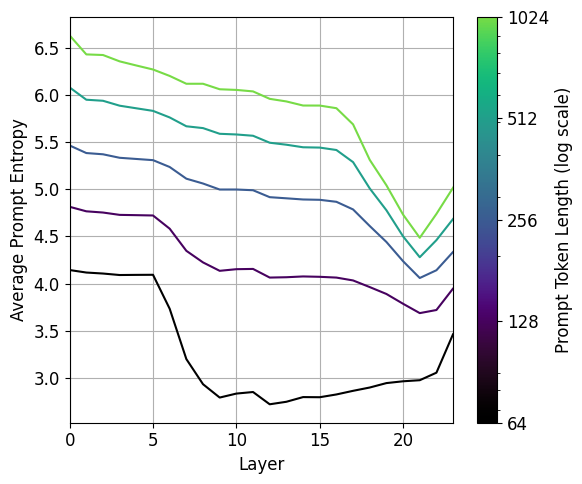

In [14]:
import matplotlib

results = pickle.load(open(f'pythia_random_of_differing_lengths.pkl', 'rb'))
results.pop(2048)

fig, ax = plt.subplots(figsize=(6, 5))
lengths = list(results.keys())
log_lengths = np.log2(lengths)  # Convert lengths to log scale
colors = cmr.lavender(np.linspace(0, 1, len(lengths)))
cmap = cmr.lavender
norm =  matplotlib.colors.LogNorm(vmin=min(lengths), vmax=max(lengths))

normalization = 'raw'

for idx, (length, entropy) in enumerate(results.items()):
    ax.plot(entropy[normalization].mean(axis=0), color=colors[idx], label=f'Length: {length}')

ax.set_xlabel("Layer")
if normalization == 'maxEntropy':
    ax.set_ylabel("Average Normalized Prompt Entropy")
    ax.set_ylim(0, 1)
else:
    ax.set_ylabel("Average Prompt Entropy")
ax.set_xlim(0, 23)
ax.grid()

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Prompt Token Length (log scale)')
cbar.set_ticks(lengths)
cbar.set_ticklabels(lengths)
plt.tight_layout()
plt.savefig(f'figures/pythia_random_of_differing_lengths_{normalization}.pdf')

## Behavior of matrix-based entropy

In [10]:
print(get_eigenvalues_with_power_law(100, 1))
print(np.linspace(1, 100, 100)**-0)

# the equation for the sum of the linsapce is 
# N 
print(1**(-1))
print(2**(-1))
print(3**(-1))
print(4**(-1))
print(5**(-1))
print(6**(-1))
print(7**(-1))
print(8**(-1))
print(9**(-1))
print(10**(-1))

[0.19277564 0.09638782 0.06425855 0.04819391 0.03855513 0.03212927
 0.02753938 0.02409695 0.02141952 0.01927756 0.01752506 0.01606464
 0.0148289  0.01376969 0.01285171 0.01204848 0.01133974 0.01070976
 0.01014609 0.00963878 0.00917979 0.00876253 0.00838155 0.00803232
 0.00771103 0.00741445 0.00713984 0.00688484 0.00664744 0.00642585
 0.00621857 0.00602424 0.00584169 0.00566987 0.00550788 0.00535488
 0.00521015 0.00507304 0.00494297 0.00481939 0.00470184 0.0045899
 0.00448315 0.00438126 0.0042839  0.00419077 0.00410161 0.00401616
 0.0039342  0.00385551 0.00377991 0.00370722 0.00363728 0.00356992
 0.00350501 0.00344242 0.00338203 0.00332372 0.00326738 0.00321293
 0.00316026 0.00310928 0.00305993 0.00301212 0.00296578 0.00292084
 0.00287725 0.00283494 0.00279385 0.00275394 0.00271515 0.00267744
 0.00264076 0.00260508 0.00257034 0.00253652 0.00250358 0.00247148
 0.0024402  0.0024097  0.00237995 0.00235092 0.0023226  0.00229495
 0.00226795 0.00224158 0.00221581 0.00219063 0.00216602 0.00214

In [2]:
def get_eigenvalues_with_power_law(N, beta):
    """
    Make a matrix with eigenvalues that follow a power law distribution,
    same eigenvalues as idendity
    """
    eigenvalues = np.linspace(1, N, N)**-beta
    eigenvalues /= eigenvalues.sum()

    # the formula for the i-th largest eigenvalue is i**-beta
    return eigenvalues

def calculate_number_of_principal_components_to_preserve_variance(eigenvalues, threshold=0.95):
    """
    Calculate the number of principal components to preserve 95% of the variance
    """
    total_variance = eigenvalues.sum()

    variance = 0
    for i, eigenvalue in enumerate(eigenvalues):
        variance += eigenvalue
        if variance >= threshold * total_variance:
            return i + 1

    return len(eigenvalues)

def get_entropy_from_eigenvalues(eigenvalues, alpha=1):
    """
    Calculate the entropy of the eigenvalues
    """
    if alpha == 1:
        entropy = -np.sum(eigenvalues * np.log(eigenvalues))
    else:
        entropy = (1 / (1 - alpha)) * np.log(np.sum(eigenvalues**alpha))

    return entropy / np.log(len(eigenvalues))

def get_logdet_entropy_from_eigenvalues(eigenvalues):
    """
    Calculate the entropy of the eigenvalues using the log determinant
    """
    N = len(eigenvalues)
    logdet = np.sum(np.log(1+eigenvalues))
    logdet -= np.log(2)
    return logdet


[0.30188590475686417, 0.3018364521564717, 0.30165372739644447, 0.3012657985167685, 0.3005649019565084, 0.29939676035801777, 0.2975541255992191, 0.2947814747137939, 0.29079809820303415, 0.28534218454278604, 0.27822852292232136, 0.26940180783419787, 0.25896437065753164, 0.24716605973540062, 0.23436032932059614, 0.2209438023033099, 0.20729933411156498, 0.19375599065523408, 0.1805696746654758, 0.16792092372783496, 0.15592349177774478, 0.14463769732206477, 0.13408434760237797, 0.12425697473190889, 0.11513154350045862, 0.10667362505730871, 0.09884341387398687, 0.09159907293337854, 0.08489886126911583, 0.07870241442471027, 0.07297145712272546, 0.06767014785629977, 0.062765192871446, 0.05822582137508536, 0.05402368176524941, 0.050132696879904404, 0.04652890178318836, 0.04319027818625365, 0.04009659358123374, 0.03722924939411265, 0.03457114014751661, 0.032106524243103896, 0.02982090618053912, 0.027700929603391544, 0.02573428035848213, 0.023909598684415556, 0.022216399649939045, 0.02064500100899

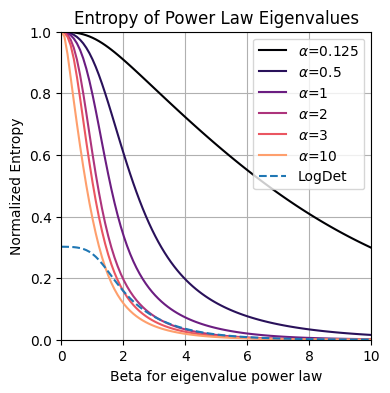

In [65]:
import matplotlib.pyplot as plt
import numpy as np
alphas = [1/8, 1/2, 1, 2, 3, 10]
betas = np.linspace(0, 10, 100)
fig, ax = plt.subplots(figsize=(4, 4))
cmap = plt.get_cmap('magma')

colors = cmap(np.linspace(0, 0.8, len(alphas)))  # Changed start from 0 to 0.2 to make endpoint darker
for alpha, color in zip(alphas, colors):
    eigenvalue_sets = [get_eigenvalues_with_power_law(100, beta) for beta in betas]
    entropies = [get_entropy_from_eigenvalues(eigenvalues, alpha) for eigenvalues in eigenvalue_sets]
    ax.plot(betas, entropies, label=f'$\\alpha$={alpha}', color=color)

logdet_entropies = [get_logdet_entropy_from_eigenvalues(eigenvalues) for eigenvalues in eigenvalue_sets]
ax.plot(betas, logdet_entropies, label='LogDet', linestyle='--')
print(logdet_entropies)
ax.set_title("Entropy of Power Law Eigenvalues")
ax.set_xlabel("Beta for eigenvalue power law")
ax.set_ylabel("Normalized Entropy")
ax.grid()
ax.set_xlim(0, 10)
ax.set_ylim(0, 1)

plt.legend()
plt.savefig('figures/power_law_entropy.pdf')

# Bimodal Training Time Hypothesis

In [4]:
model_specs = ModelSpecifications(
    model_family="Llama3",
    model_size="8B",
    revision="main"
)
model = AutoModelWrapper(model_specs, device_map="auto")

/home/AD/ofsk222/miniconda3/envs/information_plane/lib/python3.10/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Number of GPUs: 2


In [5]:
dataloader = get_dataloader(model.tokenizer, "ai-medical-dataset", split="train", num_samples=2000, min_length=30, filter_text_columns=True)
sample_perplexities = {}

with torch.no_grad():
    for idx, sample in tqdm.tqdm(enumerate(dataloader)):
        outputs = model(**sample)
        logits = outputs.logits
        labels = sample['input_ids']

        shifted_labels = labels[:, 1:].contiguous()
        shifted_logits = logits[:, :-1, :].contiguous()
        loss = torch.nn.functional.cross_entropy(shifted_logits.view(-1, shifted_logits.size(-1)), shifted_labels.view(-1))
        perplexity = torch.exp(loss)
        sample_perplexities[idx] = perplexity.item()

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/18 [00:00<?, ?it/s]

Loss: 2.1906235218048096, Perplexity: 8.940786361694336
Loss: 2.0951435565948486, Perplexity: 8.126607894897461
Loss: 3.2181813716888428, Perplexity: 24.98264503479004
Loss: 2.622467517852783, Perplexity: 13.769659042358398
Loss: 2.9829154014587402, Perplexity: 19.745298385620117
Loss: 3.024869441986084, Perplexity: 20.59131622314453
Loss: 2.767641305923462, Perplexity: 15.921036720275879
Loss: 2.835916519165039, Perplexity: 17.046016693115234
Loss: 2.0657966136932373, Perplexity: 7.891582012176514
Loss: 2.1891770362854004, Perplexity: 8.927863121032715
Loss: 1.6699672937393188, Perplexity: 5.3119940757751465
Loss: 2.7499172687530518, Perplexity: 15.641337394714355
Loss: 2.153681755065918, Perplexity: 8.616523742675781
Loss: 3.095351219177246, Perplexity: 22.09499740600586
Loss: 2.316183090209961, Perplexity: 10.136908531188965
Loss: 3.0495309829711914, Perplexity: 21.105443954467773
Loss: 2.950867176055908, Perplexity: 19.122529983520508
Loss: 2.8859636783599854, Perplexity: 17.920829

In [6]:
from datasets import load_dataset

entropy_dataloader = get_dataloader(model.tokenizer, "ai-medical-dataset", split="train", num_samples=2000, filter_text_columns=False)
entropy_samples = [sample for sample in entropy_dataloader]

ds = load_dataset("ruslanmv/ai-medical-dataset", split="train[0:2000]")
ds = ds.shuffle(seed=42)
bm25_samples = [sample for sample in ds]
sample_indices = [idx for idx, sample in enumerate(ds) if len(sample["context"]) > 5]

entropy_samples = [entropy_samples[idx] for idx in sample_indices]
bm25_samples = [bm25_samples[idx] for idx in sample_indices]

print(len(bm25_samples), len(entropy_samples))
for idx in range(len(bm25_samples)):
    assert bm25_samples[idx]["context"] == entropy_samples[idx]["context"][0], \
        f"Contexts at index {idx} do not match, {bm25_samples[idx]['context']} != {entropy_samples[idx]['context'][0]}"
    assert bm25_samples[idx]["question"] == entropy_samples[idx]["question"][0], \
        f"Questions at index {idx} do not match, {bm25_samples[idx]['question']} != {entropy_samples[idx]['question'][0]}"

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/18 [00:00<?, ?it/s]

Filter:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

1996 1996


In [7]:
import pickle
retriever_results = pickle.load(open("/home/AD/ofsk222/Research/exploration/information_plane/dataset_search/best_results.pkl", "rb"))
entropy_results = pickle.load(open("medical_entropies.pkl", "rb"))
adjusted_sample_indices = [x for x in sample_indices if x < 1000]

In [11]:
LAYER_IDX = 2
sample_idx_to_scores = {}
for idx in adjusted_sample_indices:
    sample_idx_to_scores[idx] = {
        'entropy': entropy_results['Llama3']['8B']['maxEntropy'][idx, LAYER_IDX],
        'retriever_score': (retriever_results[idx]['scores'][0] / retriever_results[idx]['scores'][19]),
        'length': len(bm25_samples[idx]["context"]) + len(bm25_samples[idx]["question"]),
        'percent_overlap': retriever_results[idx]['longest_common_substring_percent_overlap'],
        'perplexity': sample_perplexities[idx]
    }
    sample_idx_to_scores[idx]['combined_score'] = sample_idx_to_scores[idx]['retriever_score'] * sample_idx_to_scores[idx]['percent_overlap']

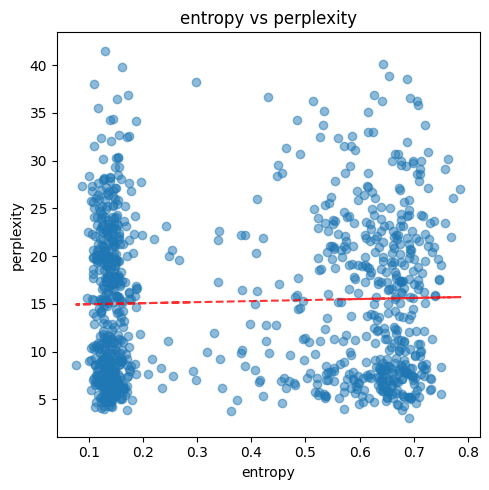

Correlation coefficient: 0.0327


In [23]:
import matplotlib.pyplot as plt

# Extract entropy and retriever scores
x_axis_col = 'entropy'
y_axis_col = 'perplexity'
entropies = [scores[x_axis_col] for scores in sample_idx_to_scores.values()]
retriever_scores = [scores[y_axis_col] for scores in sample_idx_to_scores.values()]

# Create the scatter plot
plt.figure(figsize=(5, 5))
plt.scatter(entropies, retriever_scores, alpha=0.5)
plt.xlabel(x_axis_col)
plt.ylabel(y_axis_col)
plt.title(f'{x_axis_col} vs {y_axis_col}')

# Add a trend line
z = np.polyfit(entropies, retriever_scores, 1)
p = np.poly1d(z)
plt.plot(entropies, p(entropies), "r--", alpha=0.8)

plt.tight_layout()
plt.show()

# Calculate and print correlation coefficient
correlation = np.corrcoef(entropies, retriever_scores)[0, 1]
print(f"Correlation coefficient: {correlation:.4f}")

In [19]:
# print low entropy samples
low_entropy_samples = []
for idx in adjusted_sample_indices:
    sample = entropy_samples[idx]
    formatted_sample = f"Question: {sample['question'][0]}\n\nContext: {sample['context'][0]}"
    if sample_idx_to_scores[idx]['entropy'] < 0.4:
        low_entropy_samples.append((formatted_sample, sample_idx_to_scores[idx]['entropy']))

for sample, entropy in low_entropy_samples:
    print(f"Entropy: {entropy:.4f}")
    print(sample)
    print("\n\n")

Entropy: 0.1322
Question: What is the ML-SA1 synthetic agonist?

Context: Differential mechanisms of action of the mucolipin synthetic agonist, ML-SA1, on insect TRPML and mammalian TRPML1.



Entropy: 0.1295
Question: What is the high uptake of systematic HIV Counseling and Testing and TB Symptom

Context: High Uptake of Systematic HIV Counseling and Testing and TB Symptom Screening at a Primary Care Clinic in South Africa.



Entropy: 0.1439
Question: What is the aim of this paper?

Context: AIMS AND OBJECTIVES: The aim of this paper is to explore how making reasonable adjustments to the process of securing ethical approval for research can facilitate the meaningful involvement of people with intellectual disabilities as members of a research team. This is achieved through critical reflection upon the approach taken within one participatory research study whose objective was to explore how people with intellectual disabilities understand abuse. BACKGROUND: Internationally participato

# Old

## Lets take a look at how entropy evolves as context length increases

Here I adjusting the context length of the dataset by truncating each sentence so that its resulting length is a fixed percentage of its full length. Specifically I use percentages ranging from 0.1 to 1.0, where at 0.1 the sentence is truncated to the first 10% of words, and at 1.0 the sentence is fully complete.

The goal here is to see how information content / entropy changes as we increase the length of sentences.

In [8]:
context_length_ratios = np.linspace(0.1, 1.0, 5)
context_length_entropies = []

for context_length_ratio in context_length_ratios:
    print(f"doing context length of {context_length_ratio}")
    dataset = get_dataloader(tokenizer, "wikitext", split="train", context_length_ratio=context_length_ratio, min_length=50, num_samples=25000)
    context_length_entropies.append(compute_entropies_for_each_sentence(model, dataset, alpha=1))

doing context length of 0.1


100%|██████████| 9429/9429 [01:00<00:00, 155.81it/s]


doing context length of 0.325


100%|██████████| 9429/9429 [01:07<00:00, 140.55it/s]


doing context length of 0.55


100%|██████████| 9429/9429 [01:14<00:00, 126.64it/s]


doing context length of 0.775


100%|██████████| 9429/9429 [01:38<00:00, 95.66it/s] 


doing context length of 1.0


100%|██████████| 9429/9429 [01:32<00:00, 102.27it/s]


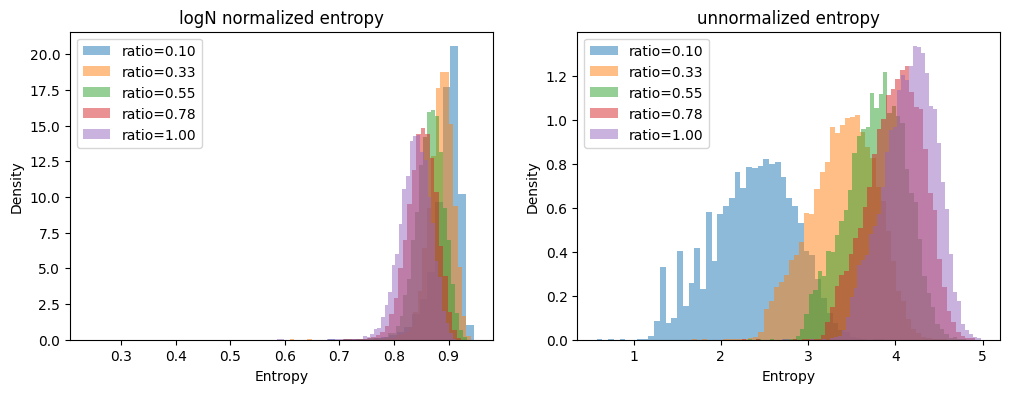

In [9]:
# plot the average entropy vs context length increases
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for context_length_ratio, context_length_entropy in zip(context_length_ratios, context_length_entropies):
    ax[0].hist(context_length_entropy['logN_normalized'], bins=50, density=True, alpha=0.5, label=f"ratio={context_length_ratio:.2f}")
    ax[1].hist(context_length_entropy['unnormalized'], bins=50, density=True, alpha=0.5, label=f"ratio={context_length_ratio:.2f}")

ax[0].set_title('logN normalized entropy')
ax[0].set_xlabel("Entropy")
ax[0].set_ylabel("Density")
ax[0].legend()

ax[1].set_title('unnormalized entropy')
ax[1].set_xlabel("Entropy")
ax[1].set_ylabel("Density")
ax[1].legend()

The above graph is pretty cool because the left and right sides have different trends. The left side roughly captures "entropy per word", which decreases as sentence lengths increase. The right side captures "total entropy", which increases as sentence lengths increase.

Below, I am plotting the average entropies vs context length

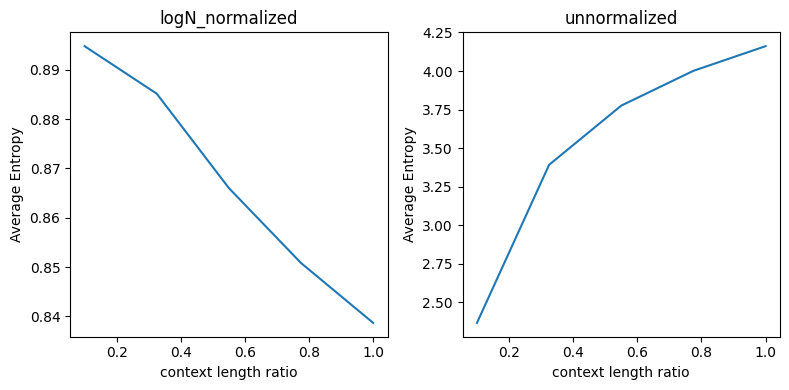

In [10]:
average_logD_entropies = [np.mean(context_length_entropy['logD_normalized']) for context_length_entropy in context_length_entropies]
average_logN_enropies = [np.mean(context_length_entropy['logN_normalized']) for context_length_entropy in context_length_entropies]
average_unnormalized_entropies = [np.mean(context_length_entropy['unnormalized']) for context_length_entropy in context_length_entropies]

fig, axes = plt.subplots(1, 2, figsize=(8,4))
keys = ['logN_normalized', 'unnormalized']
for ax, key in zip(axes.flatten(), keys):
    average_entropy = [np.mean(context_length_entropy[key]) for context_length_entropy in context_length_entropies]
    ax.plot(context_length_ratios, average_entropy)
    ax.set_title(key)
    ax.set_xlabel("context length ratio")
    ax.set_ylabel("Average Entropy")
    
plt.tight_layout()
plt.show()

## How does one word repeated many times behave?

Here I take the word "buffalo" and repeat it several times. The goal is to see how sentences constructed this way behave compared to regular sentences.

In [11]:
import random

special_word = "serat"
lengths = list(range(2, 100))
entropies = []

entropy_dict = {
        'unnormalized': [],
        'logN_normalized': [],
        'logD_normalized': [],
        'logNlogD_normalized': [],
        'lengths': []
    }

for length in lengths:
    input_string = ' '.join([special_word] * length)

    tokenized_string= tokenizer(input_string, truncation=False, return_tensors='pt')
    tokenized_string = {k: v.to(device) for k, v in tokenized_string.items()}

    with torch.no_grad():
        outputs = model(**tokenized_string)
        hidden_states = outputs.hidden_states
        N, D = hidden_states[0].shape[1:]

        last_hidden_state = normalize(outputs.last_hidden_state.squeeze())
        if N > D:
            cov = last_hidden_state.T @ last_hidden_state
        else:
            cov = (last_hidden_state @ last_hidden_state.T)
        cov /= torch.trace(cov)
        entropy = itl.matrixAlphaEntropy(cov, alpha=1)

        entropy_dict['unnormalized'].append(entropy.item())
        entropy_dict['logN_normalized'].append(entropy.item() / math.log(N))
        entropy_dict['logD_normalized'].append(entropy.item() / math.log(D))
        entropy_dict['logNlogD_normalized'].append(entropy.item() / (math.log(N)*math.log(D)))
        entropy_dict['lengths'].append(N)

Text(0.5, 0.98, "Entropy Behavior of Repeating 'serat'")

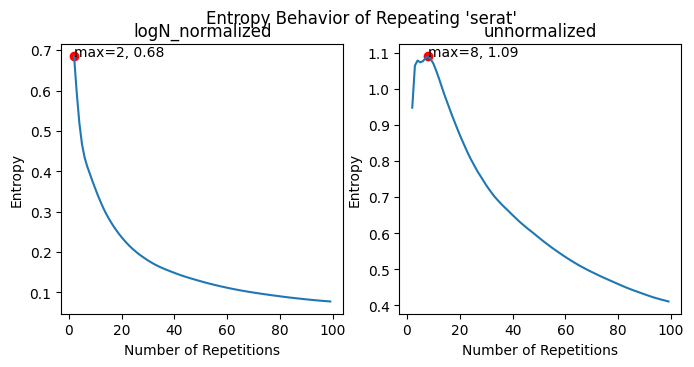

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
keys = ['logN_normalized', 'unnormalized']
for ax, key in zip(axes.flatten(), keys):
    ax.plot(lengths, entropy_dict[key])
    ax.set_title(key)
    ax.set_xlabel("Number of Repetitions")
    ax.set_ylabel("Entropy")

    # show max point
    max_index = np.argmax(entropy_dict[key])
    ax.scatter(lengths[max_index], entropy_dict[key][max_index], color='red')
    ax.annotate(f"max={max_index+2}, {entropy_dict[key][max_index]:.2f}", (lengths[max_index], entropy_dict[key][max_index]))

fig.suptitle(f"Entropy Behavior of Repeating '{special_word}'")

## Entropy of Sentences with Random Words

In [13]:
import random

lengths = 200
number_of_random_sentences = 2

random_sentences = [[tokenizer.decode(random.randint(100, 30000)) for x in range(lengths)] for _ in range(number_of_random_sentences)]
random_sentences[1] = "Elden Ring contains crafting mechanics; the creation of items requires materials. Recipes, which are required for the crafting of items, can be found inside collectibles called cookbooks, which are scattered throughout the world. Materials can be collected by defeating enemies, exploring the game's world, or by trading with merchant NPCs. Crafted items include poison darts, exploding pots, and consumables that temporarily increase the player's combat strength.[17][18] Similar to the Dark Souls games, the player can summon friendly NPCs called spirits to fight enemies.[19] Summoning each type of spirit requires its equivalent Spirit Ash; different types of Spirit Ashes can be discovered as the player explores the game world. Spirits can only be summoned near structures called Rebirth Monuments, which are primarily found in large areas and inside boss fight arenas.[20] ".split(" ")
entropy_dict = [{
        'unnormalized': [],
        'logN_normalized': [],
        'logD_normalized': [],
        'logNlogD_normalized': [],
        'lengths': []
    } for _ in range(number_of_random_sentences)]

num_tokens = [[] for _ in range(number_of_random_sentences)]

for i in range(number_of_random_sentences):
    for length in range(2, lengths):
        input_string = ' '.join(random_sentences[i][:length])

        tokenized_string= tokenizer(input_string, truncation=False, return_tensors='pt')
        tokenized_string = {k: v.to(device) for k, v in tokenized_string.items()}

        with torch.no_grad():
            outputs = model(**tokenized_string)
            hidden_states = outputs.hidden_states
            N, D = hidden_states[0].shape[1:]
            num_tokens[i].append(N)
            
            last_hidden_state = normalize(outputs.last_hidden_state.squeeze())
            if N > D:
                cov = last_hidden_state.T @ last_hidden_state
            else:
                cov = (last_hidden_state @ last_hidden_state.T)
            cov /= torch.trace(cov)
            entropy = itl.matrixAlphaEntropy(cov, alpha=1)

            entropy_dict[i]['unnormalized'].append(entropy.item())
            entropy_dict[i]['logN_normalized'].append(entropy.item() / math.log(N))
            entropy_dict[i]['logD_normalized'].append(entropy.item() / math.log(D))
            entropy_dict[i]['logNlogD_normalized'].append(entropy.item() / (math.log(N)*math.log(D)))
            entropy_dict[i]['lengths'].append(N)

Text(0.5, 0.98, 'Entropy Behavior of Random Sentence')

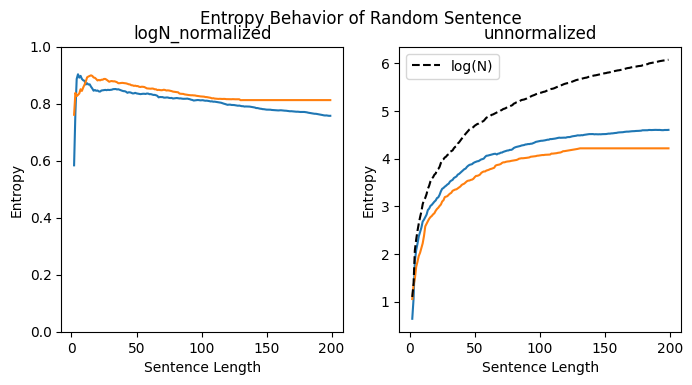

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3.7))
keys = ['logN_normalized', 'unnormalized']
for ax, key in zip(axes.flatten(), keys):
    for i in range(number_of_random_sentences):
        ax.plot(list(range(2, lengths)), entropy_dict[i][key])
    
    
    ax.set_title(key)
    ax.set_xlabel("Sentence Length")
    ax.set_ylabel("Entropy")

axes[0].set_ylim(0, 1)
axes[1].plot( list(range(2, 200)), np.log(num_tokens[0]), color='black', linestyle='--', label='log(N)')
axes[1].legend()
fig.suptitle(f"Entropy Behavior of Random Sentence")

The above graph is interesting because the overall entropy here is going down. This is a little strange, but kind of makes sense because increasing the number of repetitions doesn't add information

## Is there an eigenvector that encodes repetition?

Here I repeat the word "buffalo" 10 times. I embed the sentence and compute the covariance eigenvectors

In [15]:
special_word = "buffalo"

input_string = ' '.join([special_word] * 10)
tokenized_string= tokenizer(input_string, truncation=False, return_tensors='pt')
tokenized_string = {k: v.to(device) for k, v in tokenized_string.items()}

with torch.no_grad():
    outputs = model(**tokenized_string)
    hidden_states = outputs.hidden_states
    N, D = hidden_states[0].shape[1:]

    last_hidden_state = normalize(outputs.last_hidden_state.squeeze())

    cov = (last_hidden_state.T @ last_hidden_state)
    cov /= torch.trace(cov)
    entropy = itl.matrixAlphaEntropy(cov, alpha=1)

    # get eigs and vecs of cov
    eigs, vecs = torch.linalg.eigh(cov)
    eigs, indices = torch.sort(eigs, descending=True)
    vecs = vecs[:, indices].T


    buffalo_length_10_eigenvectors = vecs

So far we have the eigenvectors for the sentence "buffalo" repeated 10 times. Next we will see how those eigenvectors evolve as the number of repetitions increases. We will also see how they look on different words.

In [16]:
import numpy as np

special_words = ["buffalo", "oscar", "giraffe", "vehicle", "buff"]
lengths = list(range(10, 100))
entropies = []

repeated_eigenvals_over_time = np.zeros((len(special_words), D, len(lengths)))

with torch.no_grad():
    for word_idx, word in enumerate(special_words):
        for length in tqdm.tqdm(lengths):
            input_string = ' '.join([word] * length)
            tokenized_string= tokenizer(input_string, truncation=False, return_tensors='pt')
            tokenized_string = {k: v.to(device) for k, v in tokenized_string.items()}


            outputs = model(**tokenized_string)
            hidden_states = outputs.hidden_states
            N, D = hidden_states[0].shape[1:]

            last_hidden_state = normalize(outputs.last_hidden_state.squeeze())

            cov = (last_hidden_state.T @ last_hidden_state)
            cov /= torch.trace(cov)

            for vec_idx, vec in enumerate(buffalo_length_10_eigenvectors):
                # rayleigh quotient
                repeated_eigenvals_over_time[word_idx][vec_idx][length-10] = (vec.T @ cov @ vec) / (vec.T @ vec)

  0%|          | 0/90 [00:00<?, ?it/s]/tmp/ipykernel_420361/928814728.py:28: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3675.)
  repeated_eigenvals_over_time[word_idx][vec_idx][length-10] = (vec.T @ cov @ vec) / (vec.T @ vec)
100%|██████████| 90/90 [00:04<00:00, 20.35it/s]


Now we take the top 5 eigenvectors and see how they evolve for our repeated sentences and our dataset sentences as length increases.

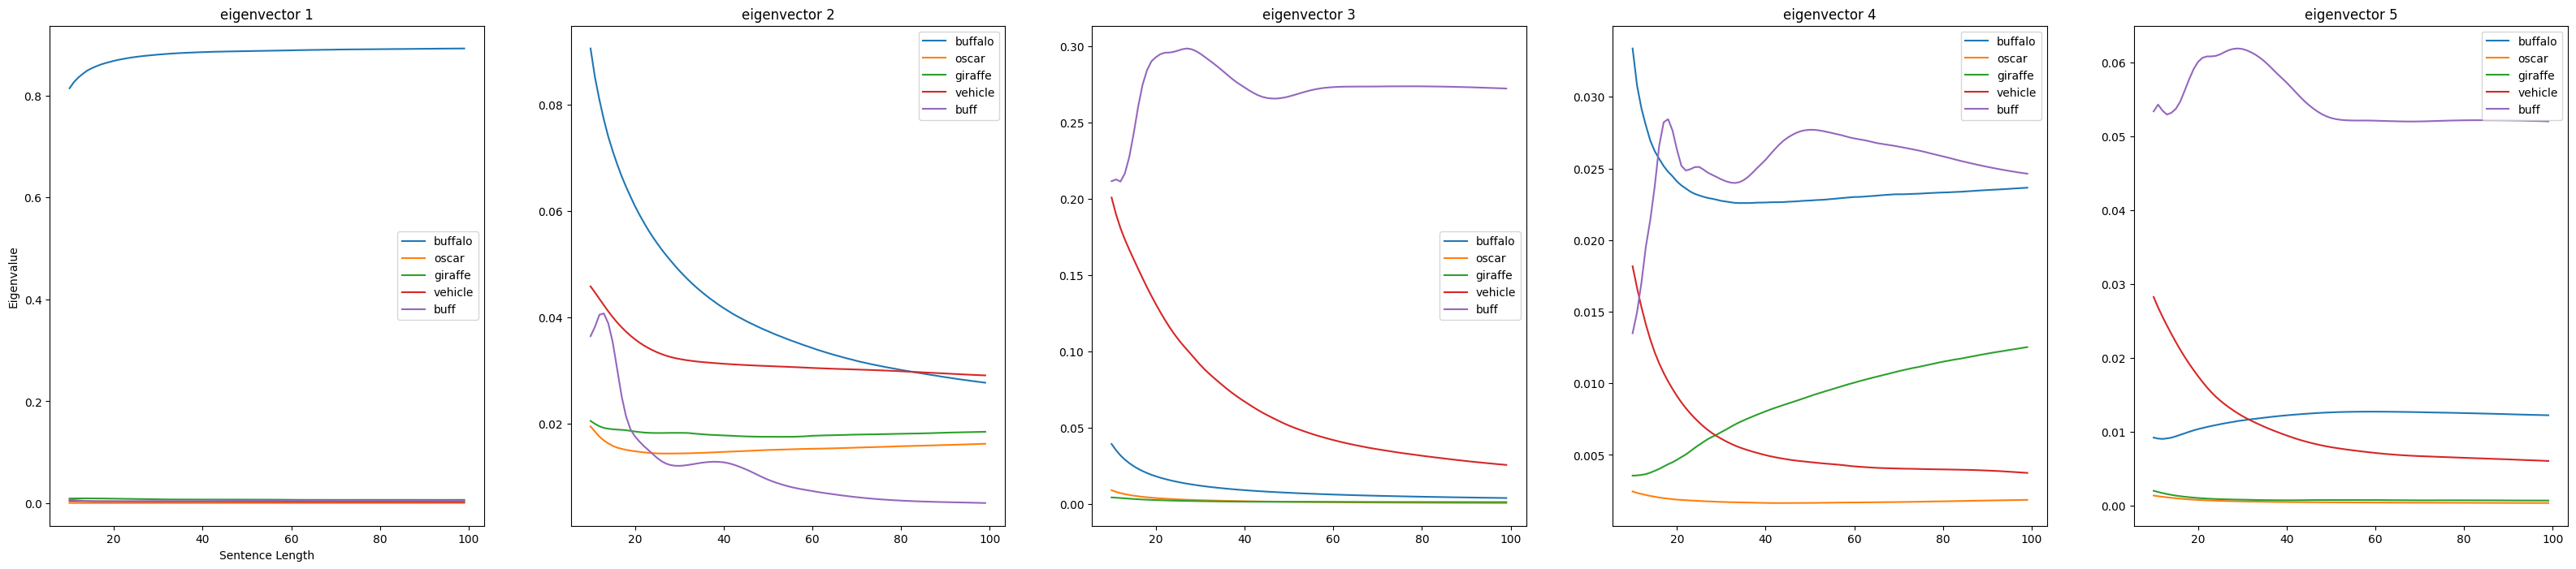

In [17]:
eig_idx_min, eig_idx_max = 0, 5

fig, axes = plt.subplots(1, eig_idx_max-eig_idx_min, figsize=( len(special_words)*8, 8))

for vec_idx in range(eig_idx_min, eig_idx_max):
    for word_idx, word in enumerate(special_words):
        axes[vec_idx-eig_idx_min].plot(lengths, repeated_eigenvals_over_time[word_idx][vec_idx], label=word)
    axes[vec_idx-eig_idx_min].legend()
    axes[vec_idx-eig_idx_min].set_title(f"eigenvector {vec_idx+1}")

    # all_average_entropies = [np.mean(x) for x in all_vals]
    # axes[1].scatter(lengths, all_average_entropies)

axes[0].set_xlabel("Sentence Length")
axes[0].set_ylabel("Eigenvalue")

plt.show()

## Lets take a look at how entropy changes as model size is increased

In [18]:
logN_sample_entropies = {k: [] for k in EleutherAI_sizes}
logD_sample_entropies = {k: [] for k in EleutherAI_sizes}
logNlogD_sample_entropies = {k: [] for k in EleutherAI_sizes}
unnormalized_sample_entropies = {k: [] for k in EleutherAI_sizes}

dimensionalities = {k: 0 for k in EleutherAI_sizes}

for model_size in EleutherAI_sizes:
    print("Running ", model_size)
    model_path = get_model_path("EleutherAI", model_size)

    tokenizer = AutoTokenizer.from_pretrained(model_path)
    model = AutoModel.from_pretrained(model_path, output_hidden_states=True).to(device)
    dataloader = get_dataloader(tokenizer, "wikitext", split="train", num_samples=10000)

    entropies = compute_entropies_for_each_sentence(model, dataloader, alpha=1)
    logN_sample_entropies[model_size] = entropies['logN_normalized']
    logD_sample_entropies[model_size] = entropies['logD_normalized']
    logNlogD_sample_entropies[model_size] = entropies['logNlogD_normalized']
    unnormalized_sample_entropies[model_size] = entropies['unnormalized']

    # get dimensionality of model
    with torch.no_grad():
        outputs = model(torch.zeros(1, 1).long().to(device))
        D = outputs.last_hidden_state.shape[-1]
        dimensionalities[model_size] = D

/home/AD/ofsk222/miniconda3/envs/information_plane/lib/python3.10/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


Running  14m


100%|██████████| 4781/4781 [00:37<00:00, 126.28it/s]
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


Running  70m


100%|██████████| 4781/4781 [00:43<00:00, 109.27it/s]
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


...

100%|██████████| 4781/4781 [02:36<00:00, 30.54it/s]
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


Running  1.4b


100%|██████████| 4781/4781 [03:34<00:00, 22.27it/s]
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


Running  2.8b


100%|██████████| 4781/4781 [06:43<00:00, 11.84it/s]


{'14m': [3.8692543506622314, 3.6328611373901367, 2.339193820953369, 3.885383129119873, 2.878840684890747, 3.8566737174987793, 3.889009952545166, 3.6795926094055176, 3.9224884510040283, 3.8953118324279785, 2.8657093048095703, 3.697323799133301, 3.654961109161377, 3.722017288208008, 3.8673248291015625, 1.33971107006073, 3.8929708003997803, 3.799168348312378, 3.7857189178466797, 3.654536247253418, 3.9040327072143555, 3.9614477157592773, 3.7439045906066895, 2.4874210357666016, 2.6573739051818848, 3.763307571411133, 3.7938902378082275, 4.0495524406433105, 3.8325979709625244, 3.0270471572875977, 3.932511329650879, 3.8484456539154053, 3.4428045749664307, 2.8652758598327637, 3.606024742126465, 3.43864369392395, 3.7844247817993164, 3.986207962036133, 2.713808059692383, 3.8599557876586914, 3.362621784210205, 3.8816514015197754, 1.605427861213684, 3.9615771770477295, 3.8635666370391846, 3.855802059173584, 3.0777132511138916, 3.4868011474609375, 3.731959819793701, 2.448124647140503, 3.732563495635

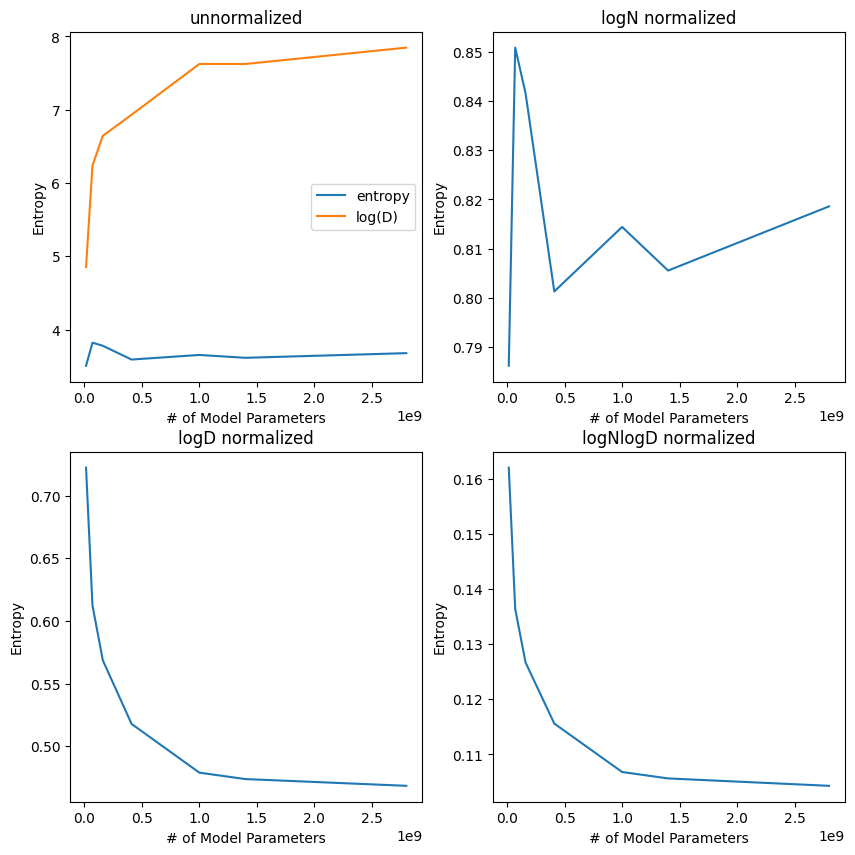

In [19]:
logN_average_entropies = [np.mean(logN_sample_entropies[k]) for k in logN_sample_entropies.keys()]
logD_average_entropies = [np.mean(logD_sample_entropies[k]) for k in logD_sample_entropies.keys()]
logNlogD_average_entropies = [np.mean(logNlogD_sample_entropies[k]) for k in logNlogD_sample_entropies.keys()]
unnormalized_average_entropies = [np.mean(unnormalized_sample_entropies[k]) for k in unnormalized_sample_entropies.keys()]

print(unnormalized_sample_entropies)
model_params = [int(x[:-1])*10**6 for x in ['14m', '70m', '160m', '410m', '1000m', '1400m', '2800m',]]#if x[-1]=='m' else x[:-1]*10**7]

fig, axes = plt.subplots(2, 2, figsize=(10,10))
print(np.mean(unnormalized_sample_entropies['14m']))

axes[0][0].plot(model_params, unnormalized_average_entropies, label="entropy")
axes[0][0].plot(model_params, np.log(list(dimensionalities.values())), label="log(D)")
axes[0][0].set_title("unnormalized")
axes[0][0].set_xlabel("# of Model Parameters")
axes[0][0].set_ylabel("Entropy")
axes[0][0].legend()

axes[0][1].plot(model_params, logN_average_entropies)
axes[0][1].set_title("logN normalized")
axes[0][1].set_xlabel("# of Model Parameters")
axes[0][1].set_ylabel("Entropy")

axes[1][0].plot(model_params, logD_average_entropies)
axes[1][0].set_title("logD normalized")
axes[1][0].set_xlabel("# of Model Parameters")
axes[1][0].set_ylabel("Entropy")

axes[1][1].plot(model_params, logNlogD_average_entropies)
axes[1][1].set_title("logNlogD normalized")
axes[1][1].set_xlabel("# of Model Parameters")
axes[1][1].set_ylabel("Entropy")

plt.show()